# Preamble

## Imports

In [1]:
import astropy.units as u
import astropy.constants as const
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import json

from DiscEvolution.grid import Grid
from DiscEvolution.star import SimpleStar
from DiscEvolution.eos import LocallyIsothermalEOS  
from DiscEvolution.eos import SimpleDiscEOS
from DiscEvolution.eos import IrradiatedEOS  
from DiscEvolution.disc import AccretionDisc
from DiscEvolution.viscous_evolution import ViscousEvolutionFV
from DiscEvolution.driver import PlanetDiscDriver
from DiscEvolution.io import Event_Controller
from DiscEvolution.dust import DustGrowthTwoPop, SingleFluidDrift
from DiscEvolution.viscous_evolution import HybridWindModel
from DiscEvolution.opacity import Zhu2012
from DiscEvolution.constants import yr as yr_code, GasConst, Omega0, AU, Msun  # DiscEvolution uses code units: 1 year = 2π code time units
from DiscEvolution.chemistry import SimpleCOAtomAbund, EquilibriumCOChemOberg
from DiscEvolution import planet_formation as pf
from DiscEvolution.diffusion import TracerDiffusion 
from DiscEvolution.planet_formation import Planets, Bitsch2015Model

## Useful Functions

In [2]:
def Sigma_LBP_1(r,Mdisk,Rc) -> float:
    val = (Mdisk)/(2* np.pi * Rc * r) * np.exp((-1*r)/(Rc))
    if (val.cgs.unit != (u.g / (u.cm)**2)):
        print("Sigma_1 error")
        return 0
    return val.cgs

In [3]:
import os

# Set notebook name (change this when copying to a new notebook)
_NOTEBOOK_NAME = "CASCA_planets2"
_NOTEBOOK_DIR = os.getcwd()
_OUTPUT_DIR = os.path.join(_NOTEBOOK_DIR, 'output', _NOTEBOOK_NAME)

def savefig(filename, subfolder=None, dpi=250, **kwargs):
    """Save the current figure under <notebook_dir>/output/<notebook_name>/[subfolder]/filename.
    If a file with the same name exists, appends _1, _2, _3, etc. to avoid overwriting."""
    if subfolder:
        save_dir = os.path.join(_OUTPUT_DIR, subfolder)
    else:
        save_dir = _OUTPUT_DIR
    
    # Split filename into base and extension
    base, ext = os.path.splitext(filename)
    save_path = os.path.join(save_dir, filename)
    
    # If file exists, find next available number
    counter = 1
    while os.path.exists(save_path):
        new_filename = f"{base}_{counter}{ext}"
        save_path = os.path.join(save_dir, new_filename)
        counter += 1
    
    os.makedirs(save_dir, exist_ok=True)
    plt.savefig(save_path, dpi=dpi, **kwargs)
    print(f"Saved: {save_path}")

In [4]:
#old, might need updates
def compute_alpha_turb_array(R, H, R_dz, alpha_dead, alpha_active, width_factor=1.0):
    """
    Creates a smooth alpha_turb array that transitions at R_dz.
    Transitions in log-space to ensure smooth orders of magnitude.
    
    Args:
        R: radial grid (array, AU)
        H: scale height (array, AU)
        R_dz: dead zone radius (scalar, AU)
        alpha_dead: turbulent alpha in dead zone
        alpha_active: turbulent alpha in active zone
        width_factor: transition width in units of H at R_dz
    """

    log_a_dead = np.log10(alpha_dead)
    log_a_active = np.log10(alpha_active)

    # Find the exact scale height (H) at the deadzone boundary
    H_at_rdz = np.interp(R_dz, R, H)
    
    # Tanh transition: 0 in dead zone, 1 in active zone
    transition = 0.5 * (1.0 + np.tanh((R - R_dz) / (width_factor * H_at_rdz)))
    
    # Blend in log space
    log_alpha_array = log_a_dead + transition * (log_a_active - log_a_dead)
    
    return 10**log_alpha_array

In [5]:
#old, might need updates
def compute_R_dz_linear(t_yr, R_dz_initial_AU, R_dz_min_AU, t_start_yr, t_final_yr) -> float: 
    """
    Moves Rdz linearly from initial to min over the disc lifetime.
    """

    disc_lifetime_yr = t_final_yr - t_start_yr
    distance = R_dz_initial_AU.value - R_dz_min_AU.value 
    velocity = distance / disc_lifetime_yr #Au/yr 
    t_rel = max(0.0, t_yr - t_start_yr)

    return max(R_dz_initial_AU.value - (velocity * t_rel), R_dz_min_AU.value) 

In [6]:
def compute_R_dz_exponential(t, r_floor, r_0, r_1, t0, t1):
    """
    Exponentially moves the dead-zone radius inward.

    Parameters
    ----------
    t : float
        Time in yr.
    r_floor : float
        Minimum/final dead-zone radius in AU.
    r_0 : float
        Dead-zone radius at t0 in AU.
    r_1 : float
        Dead-zone radius at t1 in AU.
    t0 : float
        Initial reference time in yr.
    t1 : float
        Benchmark time in yr.

    Returns
    -------
    R_dz : float
        Dead-zone radius in AU.
    """

    if not (r_floor < r_1 < r_0):
        raise ValueError("Need r_floor < r_1 < r_0 for inward exponential decay.")

    if t1 <= t0:
        raise ValueError("Need t1 > t0.")

    tau = -(t1 - t0) / np.log((r_1 - r_floor) / (r_0 - r_floor))

    # prevent R_dz from exceeding r_0 before t0
    if t <= t0:
        return r_0

    R_dz = r_floor + (r_0 - r_floor) * np.exp(-(t - t0) / tau)

    return R_dz

# 0. Simulation Parameters

In [7]:
t_initial = 0.0 * u.Myr
t_initial_yr = t_initial.to(u.yr).value 
t_initial_code = t_initial_yr * yr_code  #Convert to code units

t_final = 2.0 * u.Myr
t_final_yr = t_final.to(u.yr).value 
t_final_code = t_final_yr * yr_code  #Convert to code units

M_disk_0 = 0.1 * u.solMass 
Rc = 50.0 * u.AU #where disc starts fading out at 0.1 Myr in order to be at 120 AU at 1Myr
Mstar = 1.2 * u.solMass
Rstar = 3.0 * u.solRad
Tstar = 4395.0 * u.K
mu = 2.33

#Reference Values
Mdot_ref = 1e-8
alpha_SS_DZ = 1e-5
R_dz = 5.0 * u.AU

r_dz_floor  = 0.3           # AU — final minimum dead zone radius
r_dz_0      = R_dz.value    # 15 AU at t=0
r_dz_1      = 1.5           # AU — dead zone radius at t1
t_dz_0      = t_initial_yr  # yr 
t_dz_1      = 1.02e6           # yr — reference time

# Create descriptive subfolder name
subfolder = f'PlanetsNoMigration_Rdz_{R_dz.value:.2f}_diskmass_{M_disk_0.value:.2f}_alphaSS_{alpha_SS_DZ:.0e}_Mdot_{Mdot_ref:.1e}'

In [8]:
#Collect simulation parameters (will be saved after grid is defined)
params = {
    "time": {
        "t_initial_Myr": t_initial.value,
        "t_final_Myr": t_final.value,
    },
    "disc": {
        "M_disk_0_Msun": M_disk_0.value,
        "Rc_AU": Rc.value
    },
    "star": {
        "Mstar_Msun": Mstar.value,
        "Rstar_Rsun": Rstar.value,
        "Tstar_K": Tstar.value
    },
    "physics": {
        "Mdot_ref_Msun_per_yr": Mdot_ref,
        "alpha_SS_DZ": alpha_SS_DZ
    },
    "output": {
        "subfolder": subfolder,
        "notebook_name": _NOTEBOOK_NAME
    }
}

# 1. Grid

In [9]:
R_in = 0.1   # AU
R_out = 1000.0  # AU — must be >> Rc (91 AU) so the spreading front never reaches the boundary
Ncells = 1000
grid = Grid(R_in, R_out, Ncells, spacing='natural')
R_centers = grid.Rc  # AU

In [10]:
#Update and save complete simulation parameters to JSON
params["disc"]["R_in_AU"] = R_in
params["disc"]["R_out_AU"] = R_out
params["disc"]["Ncells"] = Ncells

#Save to JSON file in output directory
params_path = os.path.join(_OUTPUT_DIR, subfolder, 'simulation_parameters.json')
os.makedirs(os.path.dirname(params_path), exist_ok=True)
with open(params_path, 'w') as f:
    json.dump(params, f, indent=2)

# 2. Star

In [11]:
star = SimpleStar(M = Mstar.value ,      #Msun
                  R = Rstar.value,       #Rsun
                  T_eff = Tstar.value,   #K
                  age = t_initial_yr)    #yr

# 2.2 Initial Alpha Profiles

## Get Psi from Mdot & alpha_SS (deadzone)

Analytical solution (won't use, instead recursively solve for it)
\begin{equation*}
\dot{M} = \frac{3 \pi \Sigma_0}{\Omega_K} \alpha_{SS} \bigg[ A(r_{in}) + B(r_{in})\psi \bigg]
\end{equation*}

\begin{equation*}
\dot{M} = \frac{3 \pi \Sigma_0}{\Omega_K} \alpha_{SS} \bigg[ \frac{2}{u} \frac{\partial}{\partial u}(ue^{-u}c_s^2) + u^{-1}e^{-u}c_s^2\psi \bigg]
\end{equation*}
where $u = r/r_c$

Derivation for the convergence method:

When inside the deadzone, Psi >> 1
\begin{equation*}
    \dot{M} \propto \alpha_{SS} (1 + b\psi)
\end{equation*}

\begin{equation*}
    \dot{M} \propto \alpha_{SS} (\psi)
\end{equation*}

\begin{equation*}
    \frac{\dot{M}}{\dot{M_{ref}}} \propto \frac{\alpha_{SS} (\psi)}{\alpha_{SS} (\psi_{ref})}
\end{equation*}

\begin{equation*}
    \psi_{ref} = \psi \frac{\dot{M_{ref}}}{\dot{M}}
\end{equation*}

algorithm taken from run_model_combined_29_Jul.py

In [12]:
#N.B. Reference values set in section 0

psi_guess = 0.01     #Initial Guess for Psi (what we are numerically converging to)

#Create placeholder objects
#eos 
""" eos_temp = IrradiatedEOS(
   star,
    alpha_t=alpha_SS_DZ,   
    Tc=10,                  #External/nebular temperature floor (K)
    Tmax=1500,              #max temperature cap (K)
    mu=mu,
    #gamma=1.0,
    accrete=True,           #Include viscous heating from accretion
    kappa=Zhu2012,
    e_rad= 0.9, #0.99 Maybe given new data
    psi = psi_guess
) """

eos_temp = SimpleDiscEOS(alpha_t=alpha_SS_DZ, star=star,mu=mu)
eos_temp.set_grid(grid)

Sigma_temp = np.array([Sigma_LBP_1(r * u.AU, M_disk_0, Rc).value for r in R_centers])
eos_temp.update(0, Sigma_temp)

#Disc 
disc_temp = DustGrowthTwoPop(
    grid, 
    star, 
    eos_temp, 
    eps=0.01,              #Initial dust-to-gas ratio
    Sigma=Sigma_temp,
    feedback=True,         #Dust affects gas dynamics
    f_ice=1,               #Ice fraction (affects fragmentation)
    uf_0=100,              #Fragmentation velocity for dry grains (cm/s)
    uf_ice=1000,           #Fragmentation velocity for icy grains (cm/s)
    thresh=0.5             #Threshold for ice effects
)
disc_temp._planetesimal = False #Turn off planetessimals for now
disc_temp.update(0.0)           #This is to have the pebble size and stokes number correct at t=0

#Wind 
wind_temp = HybridWindModel(psi_DW=psi_guess, 
                            lambda_DW=3.0, 
                            tol=0.5, 
                            boundary='power_law', 
                            in_bound='Mdot')
disc_temp._gas = wind_temp #Attach to _gas object

/Users/james/Documents/GitHub/DiscEvolution/DiscEvolution/eos.py:224: RuntimeWarning: divide by zero encountered in divide
  return 1. / Pr_1


## Compute Initial Mdot values from the first psi guess, Scale sigma for good total disc mass

In [13]:
#Use temp objects to compute initial Mdot given psi guess
Mdot_iteration = disc_temp.Mdot(wind_temp.viscous_velocity(disc_temp)[0])

#from run_model_combined_29_Jul.py
#scale Sigma by current Mtot just in case Sigma is not quite at the correct value to have the desired Mdisk (which often happens)
Mtot_scaling = disc_temp.Mtot() * u.g.to(u.solMass)
Sigma_temp[:] *= M_disk_0.value / Mtot_scaling

In [14]:
psi_guess, Mdot_iteration

(0.01, np.float64(-2.945204286606329e-09))

## Iterate until convergence to a psi that gives the reference Mdot

In [15]:
for i in tqdm(range(15)):
    eos_temp._psi = psi_guess           # update psi on the eos
    eos_temp.update(0, Sigma_temp)      # re-solve thermal balance with new psi
    
    # disc_temp.T, disc_temp.nu etc. now reflect the new T automatically

    wind_temp._psi = psi_guess
    Mdot_iteration = disc_temp.Mdot(wind_temp.viscous_velocity(disc_temp)[0])
    psi_guess = psi_guess * (Mdot_ref / Mdot_iteration)

    print(psi_guess, Mdot_iteration)

psi_DZ = psi_guess

  0%|          | 0/15 [00:00<?, ?it/s]

-0.03382186371644133 -2.956667345075619e-09
0.11172471991381233 -3.0272498102955633e-09
-0.40004230623405146 -2.792822613327449e-09
1.105972406069136 -3.61710928806884e-09
-9.282809805014022 -1.1914198710305964e-09
5.1788975763472545 -1.79242969534866e-08
9.646447605640589 5.368709589340419e-09
7.677573371935711 1.2564448606771795e-08
8.173503771374579 9.393246258506998e-09
8.019508841366884 1.0192025388404519e-08
8.064678531709253 9.943990711886693e-09
8.051197543690284 1.0016744078065176e-08
8.055200426819994 9.995030684629048e-09
8.054010044433907 1.0001477999629401e-08
8.054363881467053 9.999560689039689e-09


Create DZ disc with obtained psi

In [16]:
# Create the EOS
""" eos = IrradiatedEOS(
    star,
    alpha_t=alpha_SS_DZ,   
    Tc=10,                  #External/nebular temperature floor (K)
    Tmax=1500,              #max temperature cap (K)
    mu=mu,
    accrete=True,           #Include viscous heating from accretion
    kappa=Zhu2012,
    e_rad= 0.9, #0.99 Maybe given new data
    psi = psi_DZ
    )
 """
eos = SimpleDiscEOS(alpha_t=alpha_SS_DZ, star=star,mu=mu)
# update eos with grid and Sigma
eos.set_grid(grid)
Sigma = np.array([Sigma_LBP_1(r * u.AU, M_disk_0, Rc).value for r in R_centers])
eos.update(0, Sigma_temp)

# define new disc 
disc = DustGrowthTwoPop(
    grid, 
    star, 
    eos, 
    eps=0.01,              #Initial dust-to-gas ratio
    Sigma=Sigma,
    feedback=True,         #Dust affects gas dynamics
    f_ice=1,               #Ice fraction (affects fragmentation)
    uf_0=100,              #Fragmentation velocity for dry grains (cm/s)
    uf_ice=1000,           #Fragmentation velocity for icy grains (cm/s)
    thresh=0.5             #Threshold for ice effects
    )
disc._planetesimal = False #Turn off planetessimals for now
disc.update(0.0)           #This is to have the pebble size and stokes number correct at t=0

wind = HybridWindModel(psi_DW=psi_DZ, 
                        lambda_DW=3.0, 
                        tol=0.5, 
                        boundary='power_law', 
                        in_bound='Mdot')
                        
disc._gas = wind #Attach to _gas object

### alpha_DW accross entire disk

In [17]:
alpha_DW = alpha_SS_DZ * psi_DZ
#alpha_DW = alpha_DW_value * np.ones_like(grid.Rc)

print(psi_DZ, alpha_SS_DZ, alpha_DW)

8.054363881467053 1e-05 8.054363881467053e-05


# 2.3 Build deadzone, alpha_SS(R), psi(R)

compute active zone

In [18]:
#alpha_SS_AZ = 1e-2 #high turbulence
alpha_SS_AZ = 1e-3 #medium turbulence
#alpha_SS_AZ = 1e-4 #low turbulence

psi_AZ = alpha_DW / alpha_SS_AZ

print(psi_AZ, alpha_SS_AZ, alpha_DW)

0.08054363881467053 0.001 8.054363881467053e-05


Alpha_SS array (both DZ and AZ)

In [19]:
Rgrid = grid.Rc
scaleHeight = eos.H #from old convergence eos but just to get a reasonable scale height 

alpha_SS_arr = compute_alpha_turb_array(R=Rgrid, 
                        H=scaleHeight, 
                        R_dz=R_dz.value, 
                        alpha_dead=alpha_SS_DZ,
                        alpha_active= alpha_SS_AZ,
                        width_factor=2
                        )

alpha_DW_arr = alpha_DW * np.ones_like(alpha_SS_arr)

Psi array

In [20]:
psi_arr = alpha_DW_arr / alpha_SS_arr

Saved: /Users/james/Documents/GitHub/DiscEvolution/james/may2026/output/CASCA_planets2/PlanetsNoMigration_Rdz_5.00_diskmass_0.10_alphaSS_1e-05_Mdot_1.0e-08/Alpha_profiles_2.png


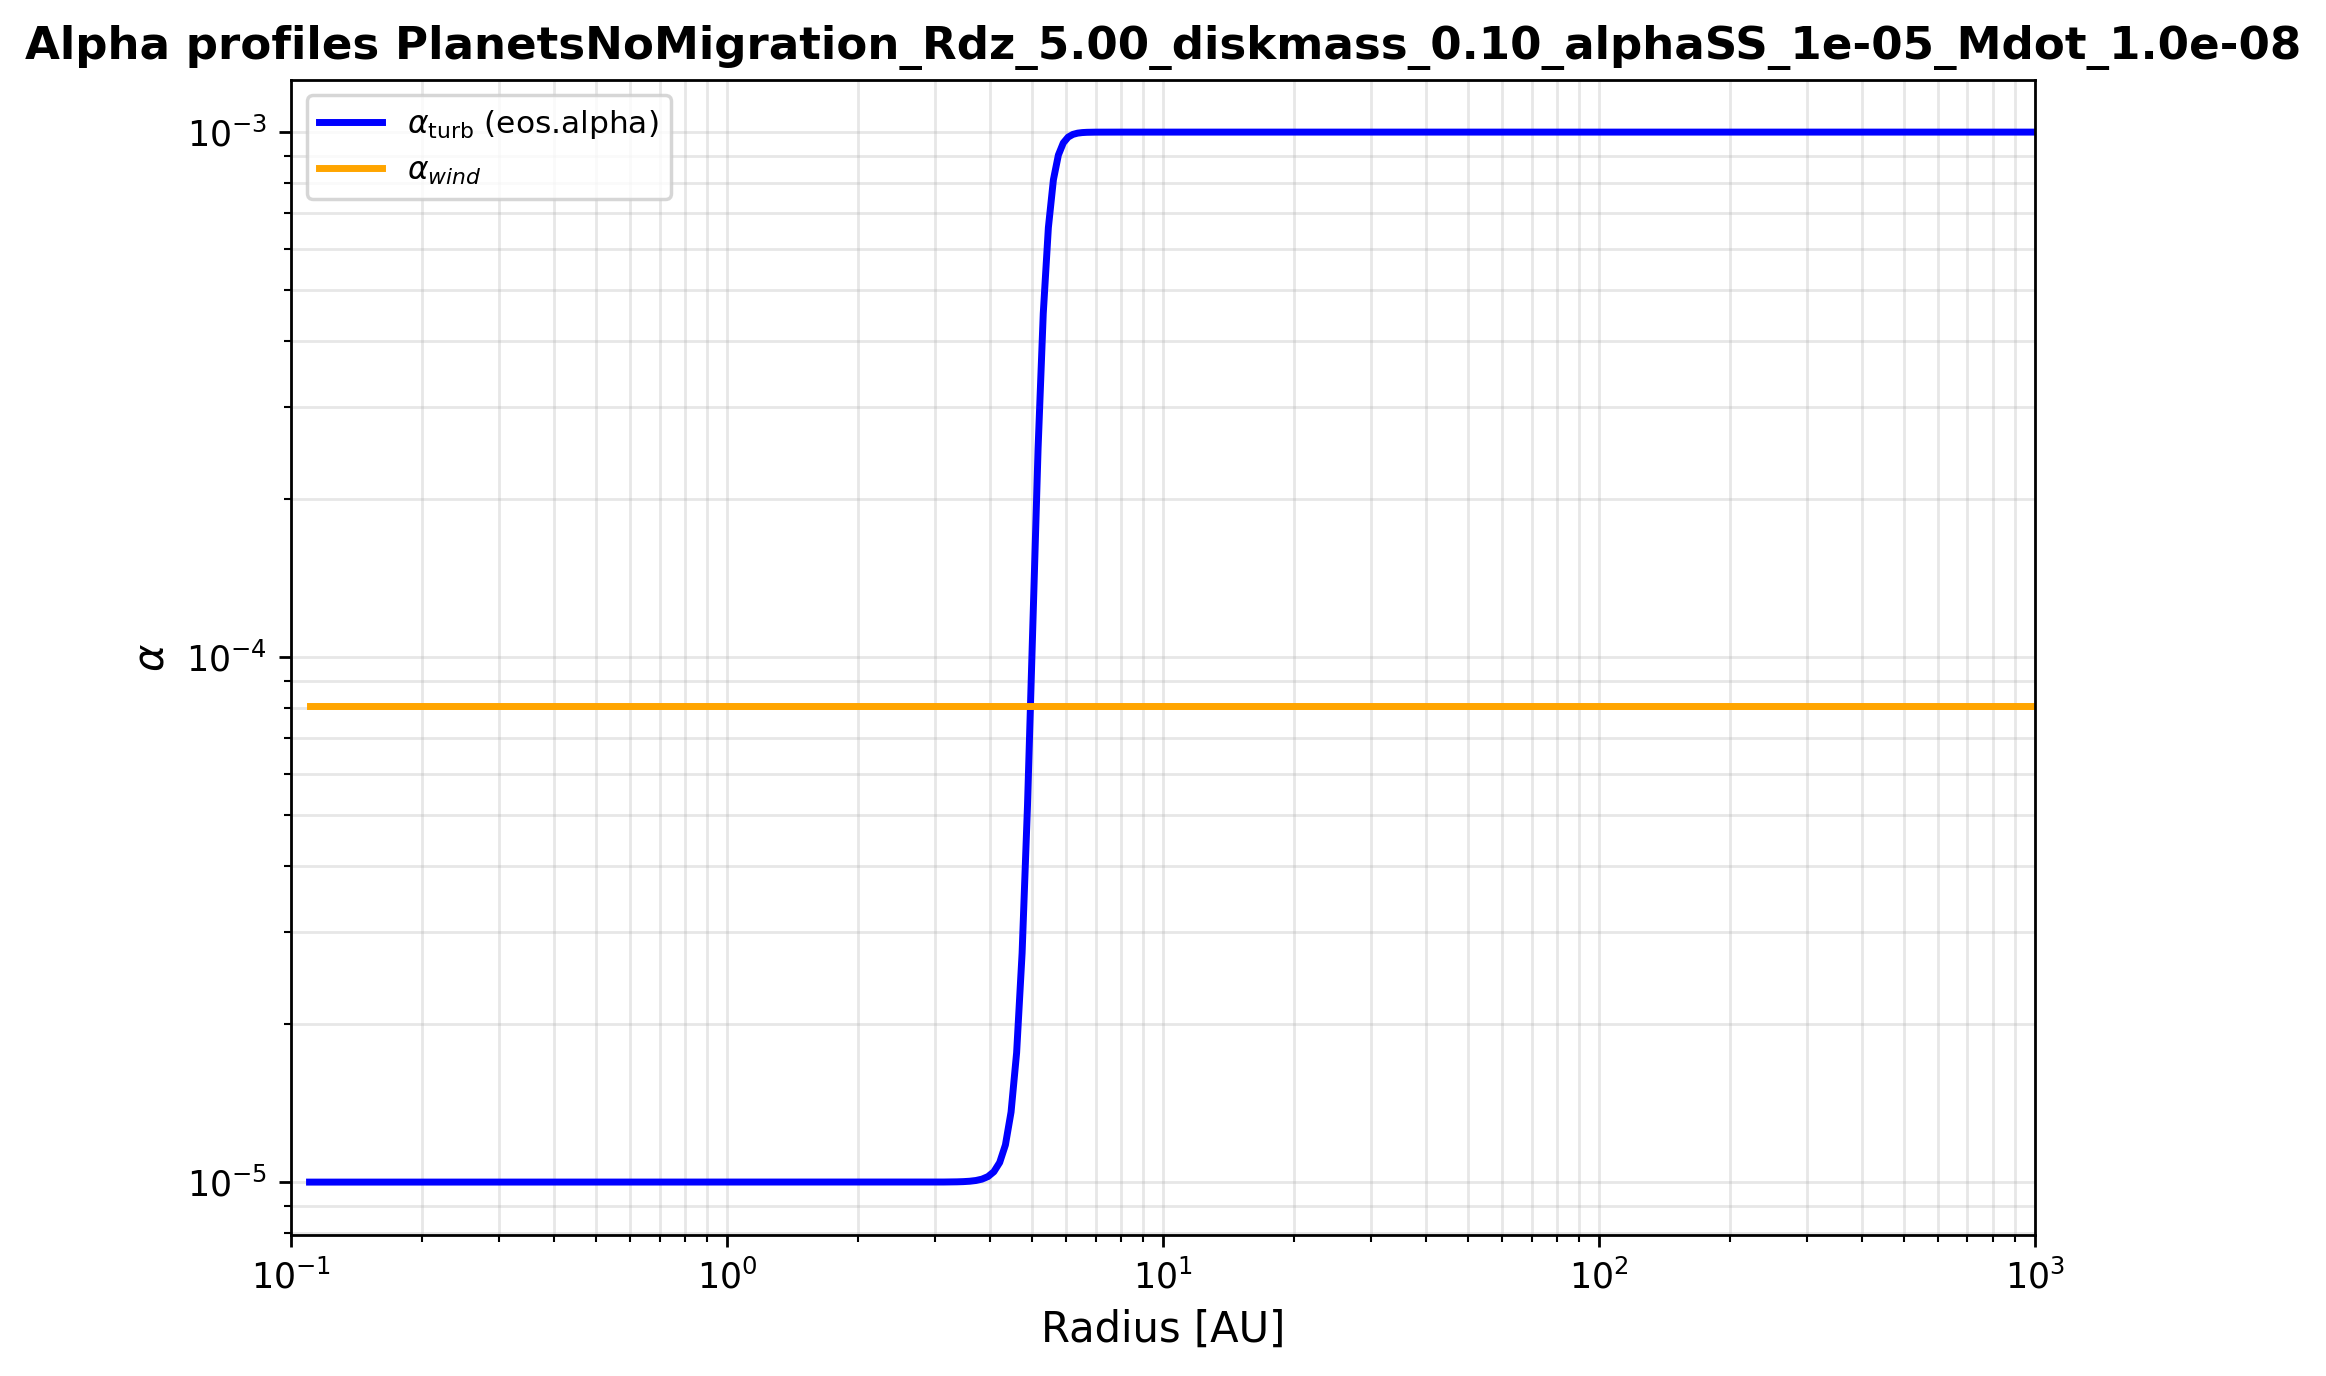

In [21]:
fig, ax = plt.subplots(figsize=(9, 6), dpi = 250)

ax.loglog(Rgrid, alpha_SS_arr, label=r'$\alpha_{\rm turb}$ (eos.alpha)', lw=2, color='blue')
ax.loglog(Rgrid, alpha_DW_arr, label=r'$\alpha_{wind}$', lw=2, color='orange')
#ax.loglog(Rgrid, alpha_eff_arr, label=r'$\alpha_{\rm eff}$ ($\alpha_{\rm turb}(1+\psi)$)', lw=2, color='red')
#ax.loglog(Rgrid, alpha_from_nu, label=r'$\nu / (c_s H)$ (back-calculated)', lw=1, ls='--', color='lime')

ax.set_xlabel('Radius [AU]', fontsize=12)
ax.set_ylabel(r'$\alpha$', fontsize=12)
ax.set_title(r'Alpha profiles '+subfolder, fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='best')
ax.grid(True, which='both', alpha=0.3)
ax.set_xlim(R_in, R_out)

savefig('Alpha_profiles.png', subfolder) 
plt.show()

Saved: /Users/james/Documents/GitHub/DiscEvolution/james/may2026/output/CASCA_planets2/PlanetsNoMigration_Rdz_5.00_diskmass_0.10_alphaSS_1e-05_Mdot_1.0e-08/Psi_profile_1.png


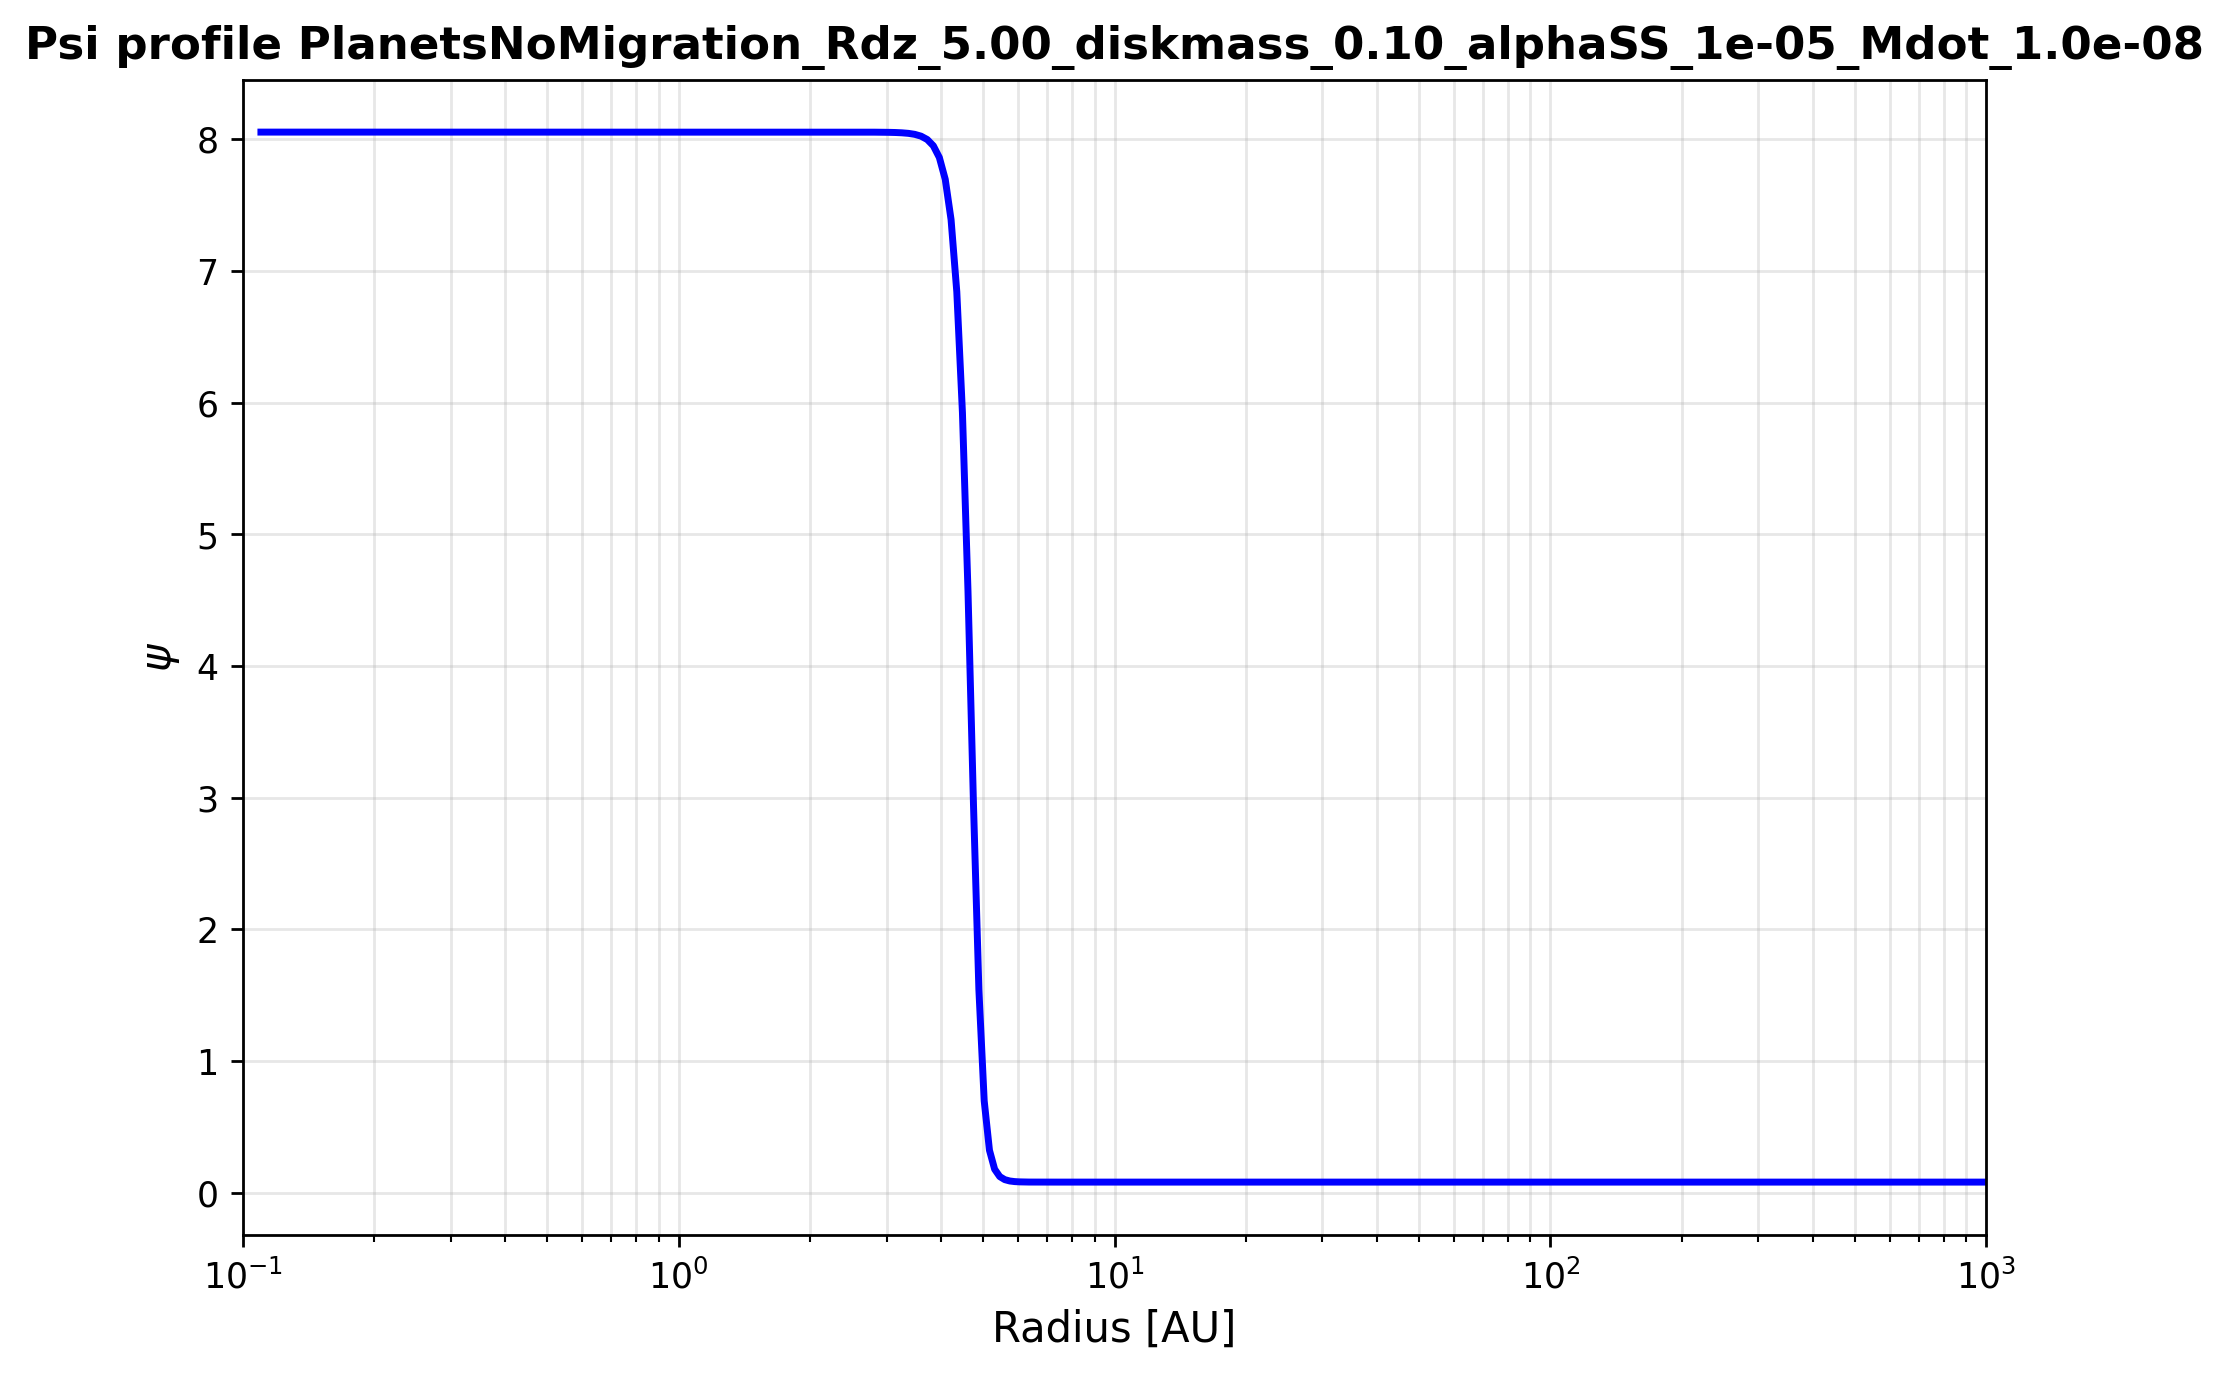

In [22]:
fig, ax = plt.subplots(figsize=(9, 6), dpi = 250)

ax.semilogx(Rgrid, psi_arr, label=r'$\alpha_{\rm turb}$ (eos.alpha)', lw=2, color='blue')

ax.set_xlabel('Radius [AU]', fontsize=12)
ax.set_ylabel(r'$\psi$', fontsize=12)
ax.set_title(r'Psi profile '+subfolder, fontsize=13, fontweight='bold')
#ax.legend(fontsize=9, loc='best')
ax.grid(True, which='both', alpha=0.3)
ax.set_xlim(R_in, R_out)
ax.set_xlim()

savefig('Psi_profile.png', subfolder) 
plt.show()

# 3. EOS

In [23]:
""" eos = IrradiatedEOS(
   star,
    alpha_t=alpha_SS_arr,   
    Tc=10,                  #External/nebular temperature floor (K)
    Tmax=1500,              #max temperature cap (K)
    mu=mu,
    #gamma=1.0,
    accrete=True,           #Include viscous heating from accretion
    kappa=Zhu2012,
    e_rad= 0.9, #0.99 Maybe given new data
    psi = psi_arr
) """

eos = SimpleDiscEOS(alpha_t=alpha_SS_arr, star=star,mu=mu)
#eos = SimpleDiscEOS(star, alpha_t=alpha_SS)
eos.set_grid(grid)

Initial EOS solve to get zero timestep and initial LBP profile

In [24]:
#LBP profile
Sigma_initial = np.array([Sigma_LBP_1(r * u.AU, M_disk_0, Rc).value for r in R_centers])

#Set this profile as timezero
eos.update(0, Sigma_initial)

# 4. Disc 

In [25]:
disc = DustGrowthTwoPop(
    grid, 
    star, 
    eos, 
    eps=0.01,              #Initial dust-to-gas ratio
    Sigma=Sigma_initial,
    feedback=True,         #Dust affects gas dynamics
    f_ice=1,               #Ice fraction (affects fragmentation)
    uf_0=100,              #Fragmentation velocity for dry grains (cm/s)
    uf_ice=1000,           #Fragmentation velocity for icy grains (cm/s)
    thresh=0.5             #Threshold for ice effects
)

disc._planetesimal = False #Turn off planetessimals for now
disc.update(0.0)           #This is to have the pebble size and stokes number correct at t=0

# 5. Viscous Evolution

In [26]:
visc_evol = HybridWindModel(psi_DW=psi_arr, 
                            lambda_DW=3.0, 
                            tol=0.5, 
                            boundary='power_law', 
                            in_bound='Mdot')

disc._gas = visc_evol #Attach to _gas object

# 6. Chemistry 

In [27]:
chem_model = EquilibriumCOChemOberg(fix_ratios=False, a=1e-5)

#Set solar abundances
X_solar = SimpleCOAtomAbund(disc.Ncells)
X_solar.set_solar_abundances()

#Iterate to convergence (ice fraction changes dust-to-gas ratio)
for i in range(10):
    chem = chem_model.equilibrium_chem(
        disc.T, 
        disc.midplane_gas_density,
        disc.dust_frac.sum(0), 
        X_solar
    )
    disc.initialize_dust_density(chem.ice.total_abund)

#Attach to disc
disc.chem = chem
disc.update_ices(disc.chem.ice)

# 7. Fluid Drift

In [28]:
drift = SingleFluidDrift(
                        diffusion=TracerDiffusion(Sc=1,limit=False),
                        settling=True,
                        van_leer=True)

# 8. Driver

In [29]:
driver = PlanetDiscDriver(
    disc, 
    gas=visc_evol, 
    dust=drift,
    chemistry=chem_model,  #Driver will handle updating chemistry for gas and ices
    t0=t_initial_code
)

# 8.5 Planets

In [30]:
planets = Planets(Nchem=0)  # or Nchem=disc.chem.ice.data.shape[0] if tracking chemistry

planet_model = Bitsch2015Model(disc, 
                                pb_gas_f=0.1, 
                                migrate=False, 
                                pebble_acc=True, 
                                gas_acc=True, 
                                winds=True)
planet_model.set_disc(disc)

In [31]:
implant_time_yr = 0.1e6  # implant planet at 0.1 Myr
planets_implanted = False

# 9. Evolution Setup

## 9.1 runtime + output times

In [32]:
run_start_yr = t_initial_yr
run_end_yr = t_final_yr
run_duration_yr = run_end_yr - run_start_yr

output_times_yr = np.linspace(run_start_yr, run_end_yr, 10)
output_times_code = output_times_yr * yr_code

io = Event_Controller(save=output_times_code)

## 9.2 Data arrays

In [33]:
history = { 
    't_yr': [],
    'Mtot': [], 
    'Rout': [],  
    'Rc': [], 
    'Sigma_G': [], 
    'Sigma_D': [], 
    'dust_frac': [], 
    'St': [], 
    'grain_size': [], 
    'T': [], 
    'P': [], 
    'chem_ice': [], 
    'chem_gas': [], 
    'mid_gas_dens': [],
    'Mdot_star': [],
    'Mdot_r': [],                          #Mdot profile at internal cell faces [Msun/yr], shape (n_snaps, Ncells-1)
    'R_faces': [],
    'R_dz': [],
    'planets_R': [],
    'planets_Mcore': [],
    'planets_Menv': [],
}

torque_maps = {
    't_yr': [],
    'maps': []
}

#Create M-R diagram for torque maps
mass_array = np.logspace(-2,3,Ncells)                   #Mearth required by compute_torque function
radius_array = disc.R                                   #AU                               
R_grid, M_grid = np.meshgrid(radius_array, mass_array)  #2D grid from the two 1D arrays

# 10. Initial Plots

## 10.1 Plotting functions

In [34]:
def plot_disc_values() -> None:
    #fig, axes = plt.subplots(3, 3, figsize=(15, 15))
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    lw = 1.5

    #color gradient
    n_snaps = len(history['t_yr'])
    alphas = np.linspace(0.1, 1.0, max(n_snaps, 1))

    # Deadzone radii
    rdz = history['R_dz']

    # 1. Surface density: Gas and Dust
    ax = axes[0, 0]
    Sg = history['Sigma_G']
    Sd = history['Sigma_D']
    for i, line in enumerate(Sg):
        ax.loglog(disc.R, Sg[i], linestyle='solid', color='C0', alpha=alphas[i],
                  label=rf"t={history['t_yr'][i]/1e6:.2f} Myr", lw=lw)
    for i, line in enumerate(Sd):
        ax.loglog(disc.R, Sd[i], linestyle='dashed', color='C1', alpha=alphas[i], lw=lw)

    for i, line in enumerate(rdz):
        ax.axvline(rdz[i], ls = ':', color = 'red', alpha=alphas[i])

    ax.set_xlabel('R [AU]')
    ax.set_ylabel(r'$\Sigma_{G,D}$ [g cm$^{-2}$]')
    ax.set_title('Surface Density')
    ax.legend(fontsize=8)
    ax.set_xlim(R_in, R_out)
    ax.set_ylim(1e-6, 10**(np.ceil(np.log10(max(np.max(Sg), np.max(Sd))))))
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', length=2)

    # 2. Dust-to-gas ratio (epsilon)
    ax = axes[0, 1]
    d2g = history['dust_frac']
    for i, line in enumerate(d2g):
        ax.loglog(disc.R, d2g[i], linestyle='solid', color='C0', alpha=alphas[i],
                  label=rf"t={history['t_yr'][i]/1e6:.2f} Myr", lw=lw)
    for i, line in enumerate(rdz):
        ax.axvline(rdz[i], ls = ':', color = 'red', alpha=alphas[i])

    ax.set_xlabel('R [AU]')
    ax.set_ylabel(r'$\epsilon$')
    ax.set_title('Total Dust/Gas Ratio')
    ax.set_xlim(R_in, R_out)
    ax.set_ylim(1e-6, 10**(np.ceil(np.log10(np.max(d2g)))))
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', length=2)

    # 3. Stokes number
    ax = axes[0, 2]
    St = history['St']
    for i, line in enumerate(St):
        ax.loglog(disc.R, St[i], linestyle='solid', color='C0', alpha=alphas[i],
                  label=rf"t={history['t_yr'][i]/1e6:.2f} Myr", lw=lw)
    for i, line in enumerate(rdz):
        ax.axvline(rdz[i], ls = ':', color = 'red', alpha=alphas[i])

    ax.set_xlabel('R [AU]')
    ax.set_ylabel('Stokes Number')
    ax.set_title('Stokes Number')
    ax.set_xlim(R_in, R_out)
    ax.set_ylim(10**(np.floor(np.log10(np.min(St)))), 10**(np.ceil(np.log10(np.max(St)))))
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', length=2)

    # 4. Pebble size
    ax = axes[1, 0]
    a = history['grain_size']
    for i, line in enumerate(a):
        ax.loglog(disc.R, a[i], linestyle='solid', color='C0', alpha=alphas[i],
                  label=rf"t={history['t_yr'][i]/1e6:.2f} Myr", lw=lw)
    for i, line in enumerate(rdz):
        ax.axvline(rdz[i], ls = ':', color = 'red', alpha=alphas[i])

    ax.set_xlabel('R [AU]')
    ax.set_ylabel('Pebble Size [cm]')
    ax.set_title('Pebble Size')
    ax.set_xlim(R_in, R_out)
    ax.set_ylim(10**(np.floor(np.log10(np.min(a)))), 10**(np.ceil(np.log10(np.max(a)))))
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', length=2)

    # 5. Pressure
    ax = axes[1, 1]
    P = np.abs(history['P'])
    for i, line in enumerate(P):
        ax.loglog(disc.R, P[i], linestyle='solid', color='C0', alpha=alphas[i],
                  label=rf"t={history['t_yr'][i]/1e6:.2f} Myr", lw=lw)
    for i, line in enumerate(rdz):
        ax.axvline(rdz[i], ls = ':', color = 'red', alpha=alphas[i])

    ax.set_xlabel('R [AU]')
    ax.set_ylabel('|P|')
    ax.set_title('Pressure')
    ax.set_xlim(R_in, R_out)
    ax.set_ylim(10**(np.floor(np.log10(np.min(P)))), 10**(np.ceil(np.log10(np.max(P)))))
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', length=2)

    # 6. Temperature profile
    ax = axes[1, 2]
    T = history['T']
    for i, line in enumerate(T):
        ax.loglog(disc.R, T[i], linestyle='solid', color='C0', alpha=alphas[i], lw=lw)
    for i, line in enumerate(rdz):
        ax.axvline(rdz[i], ls = ':', color = 'red', alpha=alphas[i])
        
    ax.axhline(170, ls='dashed', label='170 K', color='gray', lw=1)
    ax.legend(fontsize=8)
    ax.set_xlabel('R [AU]')
    ax.set_ylabel('T [K]')
    ax.set_title('Temperature Profile')
    ax.set_xlim(R_in, R_out)
    ax.set_ylim(10**(np.floor(np.log10(np.min(T)))), 2e3)
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', length=2)

    plt.suptitle('Disc Values '+subfolder, fontsize=14)
    plt.tight_layout()
    savefig('disc_values.png', subfolder)
    plt.show()

In [35]:
def plot_disc_initial_values() -> None:
    #fig, axes = plt.subplots(3, 3, figsize=(15, 15))
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    lw = 1.5

    #color gradient
    n_snaps = len(history['t_yr'])
    alphas = np.linspace(0.1, 1.0, max(n_snaps, 1))

    # 1. Surface density: Gas and Dust
    ax = axes[0, 0]
    Sg = history['Sigma_G']
    Sd = history['Sigma_D']
    for i, line in enumerate(Sg):
        ax.loglog(disc.R, Sg[i], linestyle='solid', color='C0', alpha=1,
                  label=rf"t={history['t_yr'][i]/1e6:.2f} Myr", lw=lw)
        if i >= 0:
            break
    for i, line in enumerate(Sd):
        ax.loglog(disc.R, Sd[i], linestyle='dashed', color='C1', alpha=1, lw=lw)
        if i >= 0:
            break
    ax.set_xlabel('R [AU]')
    ax.set_ylabel(r'$\Sigma_{G,D}$ [g cm$^{-2}$]')
    ax.set_title('Surface Density')
    ax.legend(fontsize=8)
    ax.set_xlim(R_in, R_out)
    ax.set_ylim(1e-6, 10**(np.ceil(np.log10(max(np.max(Sg), np.max(Sd))))))
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', length=2)

    # 2. Dust-to-gas ratio (epsilon)
    ax = axes[0, 1]
    d2g = history['dust_frac']
    for i, line in enumerate(d2g):
        ax.loglog(disc.R, d2g[i], linestyle='solid', color='C0', alpha=1,
                  label=rf"t={history['t_yr'][i]/1e6:.2f} Myr", lw=lw)
        if i >= 0:
            break
    ax.set_xlabel('R [AU]')
    ax.set_ylabel(r'$\epsilon$')
    ax.set_title('Total Dust/Gas Ratio')
    ax.set_xlim(R_in, R_out)
    ax.set_ylim(1e-6, 10**(np.ceil(np.log10(np.max(d2g)))))
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', length=2)
    ax.axvline(R_dz.value, ls = ':', color = 'red')

    # 3. Stokes number
    ax = axes[0, 2]
    St = history['St']
    for i, line in enumerate(St):
        ax.loglog(disc.R, St[i], linestyle='solid', color='C0', alpha=1,
                  label=rf"t={history['t_yr'][i]/1e6:.2f} Myr", lw=lw)
        if i >= 0:
            break
    ax.set_xlabel('R [AU]')
    ax.set_ylabel('Stokes Number')
    ax.set_title('Stokes Number')
    ax.set_xlim(R_in, R_out)
    ax.set_ylim(10**(np.floor(np.log10(np.min(St)))), 10**(np.ceil(np.log10(np.max(St)))))
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', length=2)
    ax.axvline(R_dz.value, ls = ':', color = 'red')

    # 4. Pebble size
    ax = axes[1, 0]
    a = history['grain_size']
    for i, line in enumerate(a):
        ax.loglog(disc.R, a[i], linestyle='solid', color='C0', alpha=1,
                  label=rf"t={history['t_yr'][i]/1e6:.2f} Myr", lw=lw)
        if i >= 0:
            break
    ax.set_xlabel('R [AU]')
    ax.set_ylabel('Pebble Size [cm]')
    ax.set_title('Pebble Size')
    ax.set_xlim(R_in, R_out)
    ax.set_ylim(10**(np.floor(np.log10(np.min(a)))), 10**(np.ceil(np.log10(np.max(a)))))
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', length=2)
    ax.axvline(R_dz.value, ls = ':', color = 'red')

    # 5. Pressure
    ax = axes[1, 1]
    P = np.abs(history['P'])
    for i, line in enumerate(P):
        ax.loglog(disc.R, P[i], linestyle='solid', color='C0', alpha=1,
                  label=rf"t={history['t_yr'][i]/1e6:.2f} Myr", lw=lw)
        if i >= 0:
            break
    ax.set_xlabel('R [AU]')
    ax.set_ylabel('|P|')
    ax.set_title('Pressure')
    ax.set_xlim(R_in, R_out)
    ax.set_ylim(10**(np.floor(np.log10(np.min(P)))), 10**(np.ceil(np.log10(np.max(P)))))
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', length=2)
    ax.axvline(R_dz.value, ls = ':', color = 'red')

    # 6. Temperature profile
    ax = axes[1, 2]
    T = history['T']
    for i, line in enumerate(T):
        ax.loglog(disc.R, T[i], linestyle='solid', color='C0', alpha=1, lw=lw)
        if i >= 0:
            break
    ax.axhline(170, ls='dashed', label='170 K', color='gray', lw=1)
    ax.legend(fontsize=8)
    ax.set_xlabel('R [AU]')
    ax.set_ylabel('T [K]')
    ax.set_title('Temperature Profile')
    ax.set_xlim(R_in, R_out)
    ax.set_ylim(10**(np.floor(np.log10(np.min(T)))), 2e3)
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', length=2)
    ax.axvline(R_dz.value, ls = ':', color = 'red')

    plt.suptitle('Disc Values '+subfolder, fontsize=14)
    plt.tight_layout()
    savefig('disc_values.png', subfolder)
    plt.show()


## 10.2 Check values before evolution

Saved: /Users/james/Documents/GitHub/DiscEvolution/james/may2026/output/CASCA_planets2/PlanetsNoMigration_Rdz_5.00_diskmass_0.10_alphaSS_1e-05_Mdot_1.0e-08/Alpha_profiles_3.png


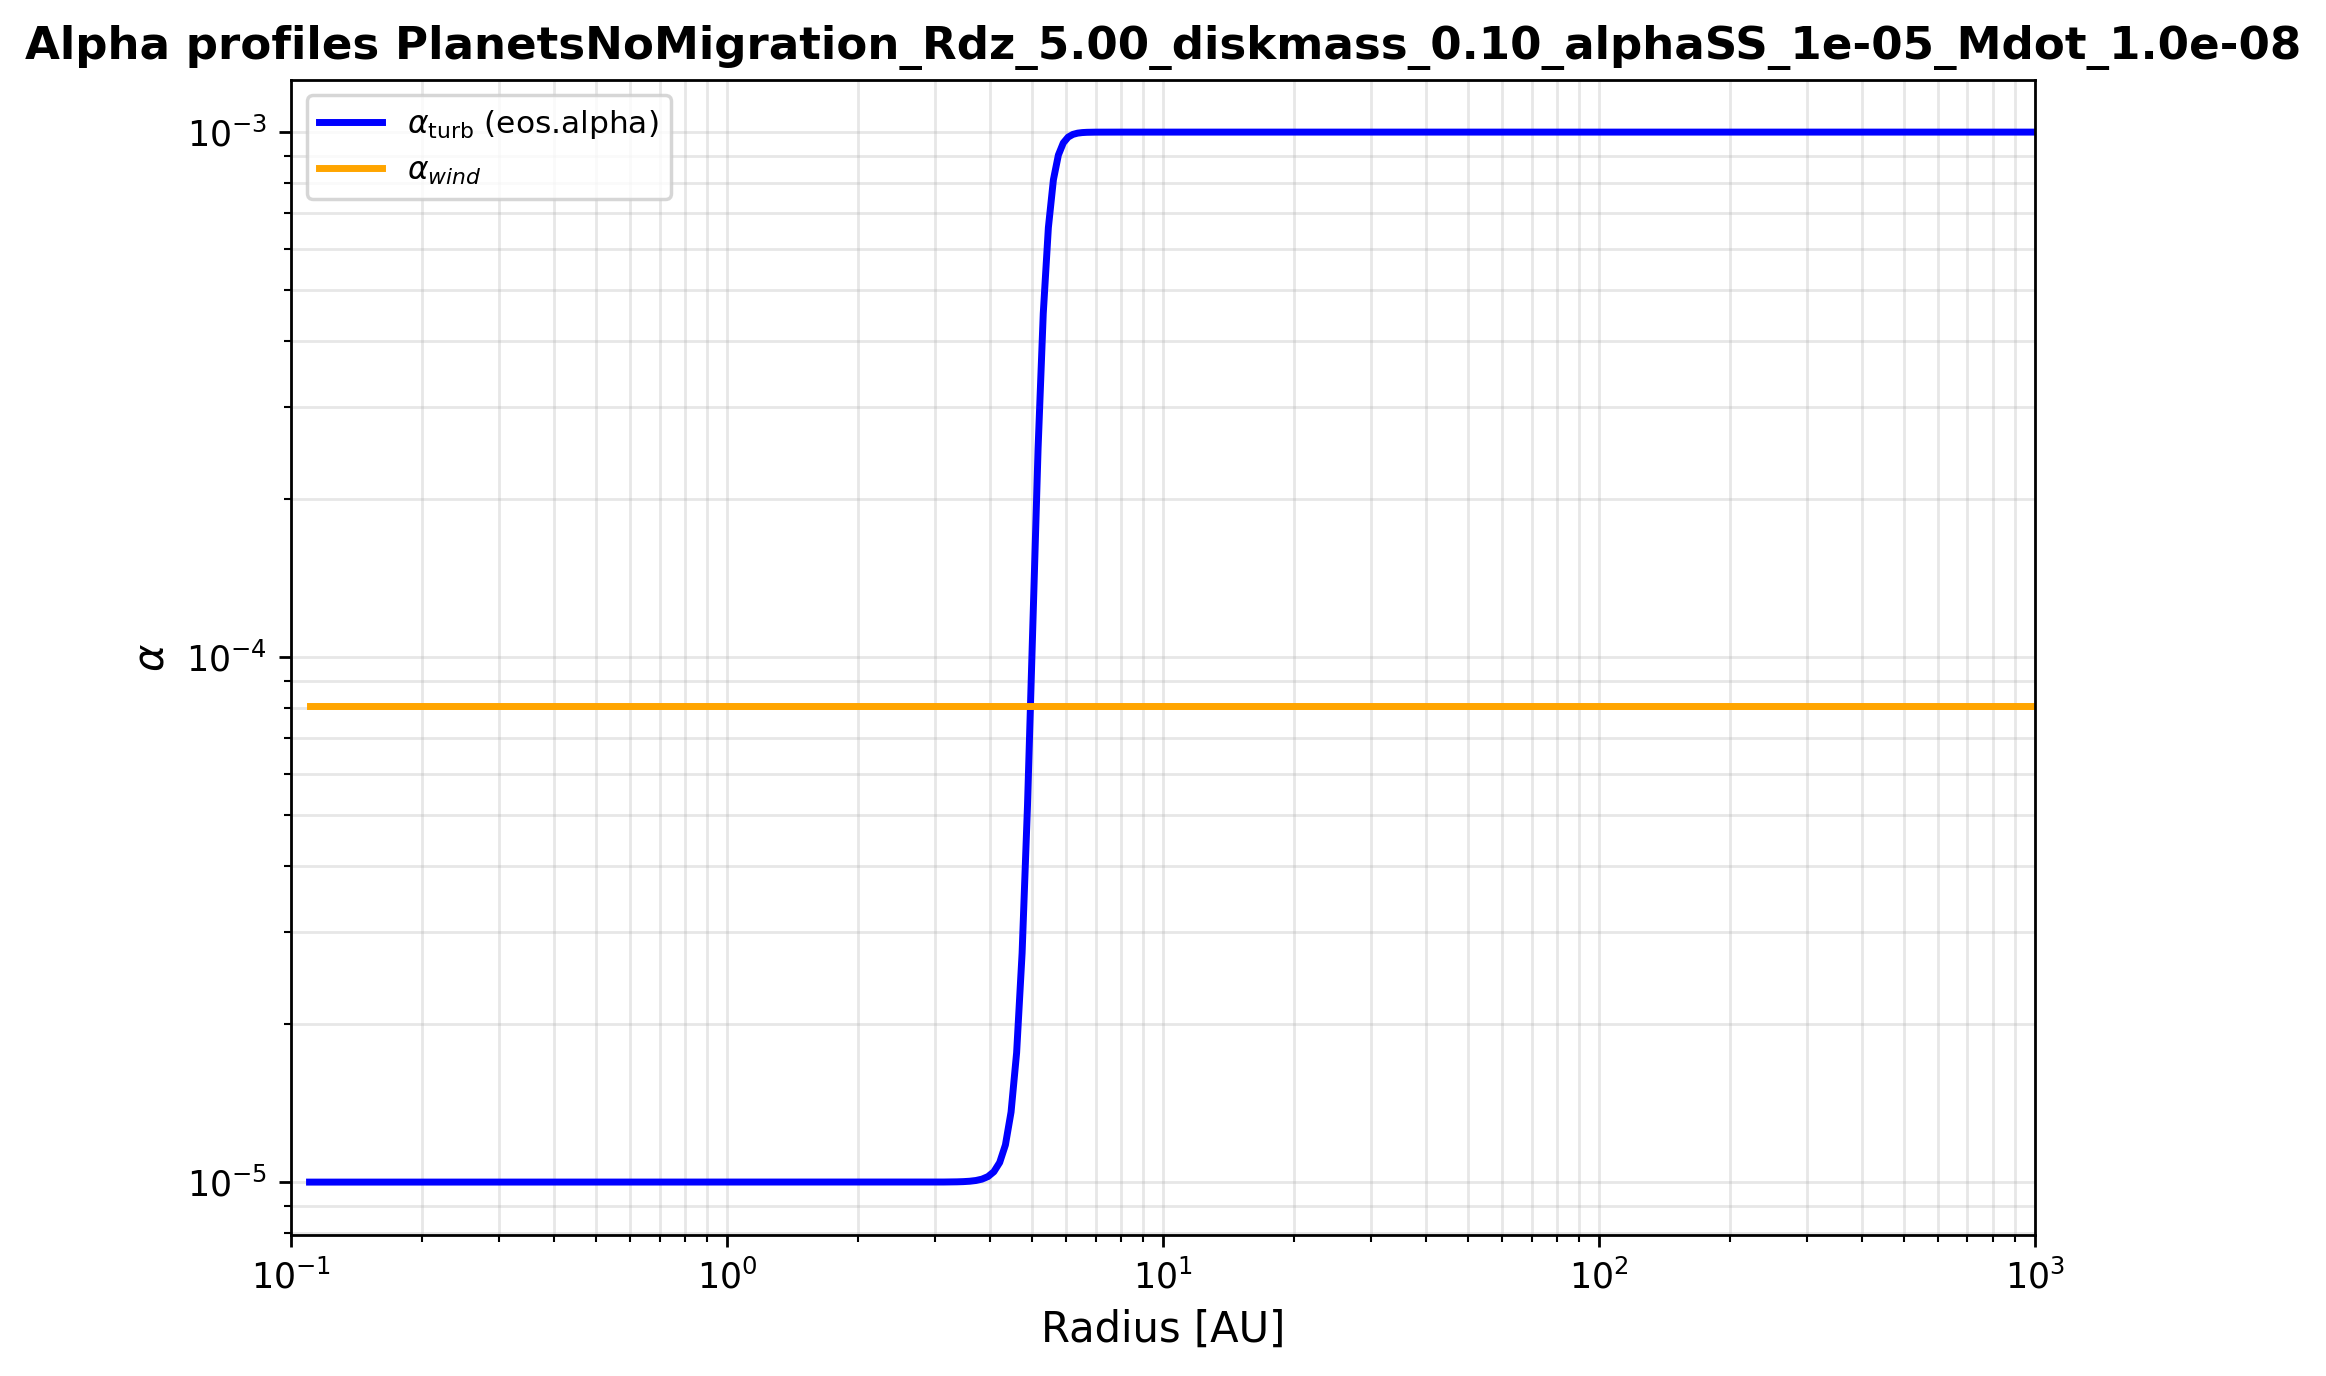

In [36]:
fig, ax = plt.subplots(figsize=(9, 6), dpi = 250)

ax.loglog(Rgrid, eos.alpha, label=r'$\alpha_{\rm turb}$ (eos.alpha)', lw=2, color='blue')
ax.loglog(Rgrid, alpha_DW_arr, label=r'$\alpha_{wind}$', lw=2, color='orange')
#ax.loglog(Rgrid, alpha_eff_arr, label=r'$\alpha_{\rm eff}$ ($\alpha_{\rm turb}(1+\psi)$)', lw=2, color='red')
#ax.loglog(Rgrid, alpha_from_nu, label=r'$\nu / (c_s H)$ (back-calculated)', lw=1, ls='--', color='lime')

ax.set_xlabel('Radius [AU]', fontsize=12)
ax.set_ylabel(r'$\alpha$', fontsize=12)
ax.set_title(r'Alpha profiles '+subfolder, fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='best')
ax.grid(True, which='both', alpha=0.3)
ax.set_xlim(R_in, R_out)

savefig('Alpha_profiles.png', subfolder) 
plt.show()

In [37]:
print(f"psi_DZ      = {psi_DZ:.5f}")
print(f"psi_AZ      = {psi_AZ:.5f}")
print(f"alpha_SS_DZ = {alpha_SS_DZ:.5e}")
print(f"alpha_SS_AZ = {alpha_SS_AZ:.5e}")
print(f"nu_DZ  at 1 AU = {eos.nu[np.argmin(np.abs(disc.R-1))]:.3e}")
print(f"nu_AZ  at 3 AU = {eos.nu[np.argmin(np.abs(disc.R-3))]:.3e}")

psi_DZ      = 8.05436
psi_AZ      = 0.08054
alpha_SS_DZ = 1.00000e-05
alpha_SS_AZ = 1.00000e-03
nu_DZ  at 1 AU = 8.423e-09
nu_AZ  at 3 AU = 2.236e-08


# 11. Evolution Loop

In [ ]:
pbar = tqdm(total=run_duration_yr,
             unit='yr',
             desc='Evolving disc... ',
             bar_format='{desc}: {percentage:.1f}%|{bar}| {rate_fmt} [{elapsed}<{remaining}]')
last_elapsed_yr = 0.0
steps = 0
t_yr = driver.t / yr_code
last_t_yr = t_yr

while not io.finished():
    ti = io.next_event_time()
    R_dz_current = R_dz.value

    while driver.t < ti:
        """ # Here is stuff needed to make DZ move inwards
        t_yr_current = driver.t / yr_code
        
        # Compute current DZ radius
        R_dz_current = compute_R_dz_exponential(
                                                t_yr_current, 
                                                r_dz_floor, #params set in section 0
                                                r_dz_0, 
                                                r_dz_1, 
                                                t_dz_0, 
                                                t_dz_1)

        R_dz_current = compute_R_dz_linear(t_yr_current,
                                        R_dz_initial_AU=R_dz, 
                                        R_dz_min_AU=0.1 * u.AU,
                                        t_start_yr=t_initial_yr,
                                        t_final_yr=t_final_yr)

        # Rebuild alpha_SS array with new DZ location
        alpha_SS_arr[:] = compute_alpha_turb_array(
                                                R=disc.R, 
                                                H=eos.H, 
                                                R_dz=R_dz_current,
                                                alpha_dead=alpha_SS_DZ, 
                                                alpha_active=alpha_SS_AZ, 
                                                width_factor=2)   

        # Recompute the psi array 
        psi_arr[:] = alpha_DW_arr / alpha_SS_arr

        # Assign new arrays to the eos and wind parameters 
        #eos._alpha_t = alpha_SS_arr ##
        #visc_evol._psi = psi_arr   ##These lines are useless since we don't create new array objects only update the ones the modules point to already

 """
        # below is necessary stuff to evolve disc with constant DZ
        dt = driver(ti)
        steps += 1

        ## Planets Stuff
        if not planets_implanted and (driver.t / yr_code) >= implant_time_yr:
            planets.add_planet(driver.t, R=5.0, Mcore=10.0, Menv=0.0)
            planets_implanted = True
            print('Planet(s) implanted.')

        if planets.N > 0:
            # Safety: check planet hasn't fallen off inner grid
            if np.any(planets.R > grid.Rc[0]):
                planet_model.set_disc(disc)   # update splines after disc evolves
                planet_model.integrate(dt, planets)

        # pbar progress
        t_yr = driver.t / yr_code
        pbar.update(t_yr - last_t_yr)
        last_t_yr = t_yr

    # Store at output times
    if io.check_event(driver.t, 'save'):
        history['t_yr'].append(driver.t / yr_code)                        #yr
        history['Mtot'].append(disc.Mtot() * u.g.to(u.solMass))           #Msol
        history['Rout'].append(disc.Rout())                               #AU
        #history['Rc'].append(disc.RC())                                  #AU
        history['Sigma_G'].append(disc.Sigma_G.copy())                    #Total gas Sigma
        history['Sigma_D'].append(disc.Sigma_D.sum(axis=0).copy())        #Total dust Sigma, pebbles + grains
        history['dust_frac'].append(disc.dust_frac.sum(axis=0).copy())    #Total dust to gas ratio
        history['St'].append(disc.Stokes()[1].copy())                     #Pebbles not small grains
        history['grain_size'].append(disc.grain_size[1].copy())           #Pebbles not small grains
        history['T'].append(disc.T.copy())                                #Temperature
        history['P'].append(disc.P.copy())                                #Pressure
        history['chem_ice'].append(disc.chem.ice.data.copy())             
        history['chem_gas'].append(disc.chem.gas.data.copy())
        history['mid_gas_dens'].append(disc.midplane_gas_density.copy())
        
        vr = visc_evol.viscous_velocity(disc)                                       #AU/code_time, Ncells-1 internal faces
        Sig_faces  = (disc.Sigma[:-1] + disc.Sigma[1:]) / 2                                 #face-averaged total Sigma [g/cm^2], skips inner edge and outer edge
        R_faces = disc.grid.Re[1:-1]                                                        #faces Radii, skips inner edge and outer edge
        history['R_faces'].append(R_faces.copy())

        history['Mdot_star'].append(disc.Mdot(vr[0]))                                  #Msun/yr at innermost face, conversion happens inside disc.Mdot()
        history['Mdot_r'].append(                                                           #Msun/yr at all faces, except innermost
            (-2.0 * np.pi * R_faces * Sig_faces * vr * AU**2 * yr_code / Msun).copy()  #same form as what goes on in disc.Mdot()
        )

        """ history['R_dz'].append(compute_R_dz_exponential(
                                                driver.t / yr_code, 
                                                r_dz_floor, #params set in section 0
                                                r_dz_0, 
                                                r_dz_1, 
                                                t_dz_0, 
                                                t_dz_1)
        ) """

        """ history['R_dz'].append(compute_R_dz_linear(driver.t / yr_code,
                                        R_dz_initial_AU=R_dz, 
                                        R_dz_min_AU=0.1 *u.AU,
                                        t_start_yr=t_initial_yr,
                                        t_final_yr=t_final_yr)
        ) """
        
        history['R_dz'].append(R_dz_current)

        history['planets_R'].append(planets.R.copy())
        history['planets_Mcore'].append(planets.M_core.copy())
        history['planets_Menv'].append(planets.M_env.copy())

        io.pop_events(driver.t, 'save')

        #Torque Maps Data 
        TypeI = pf.TypeIMigration(disc)                                                     #Creates a Type I migration object from the disc object
        Torque_map = np.zeros_like(R_grid)                                                  #initialize 2D grid with all values zero 

        for i, Mp in enumerate(mass_array):
            Mp_array = np.ones_like(radius_array) * Mp                                      #Pass Mp as an array of the same shape as radius_array           
            Torque_map[i,:] = TypeI.compute_torque_not_normalized(radius_array, Mp_array)   #Compute the total torque for said mass at each R 

        torque_maps['t_yr'].append(driver.t / yr_code)
        torque_maps['maps'].append(Torque_map)

pbar.close()


print(f"\n=== EVOLUTION COMPLETE ===")
print(f"Total steps: {steps}")
print(f"Final time: {driver.t/yr_code:.1e} years")
print(f"Final mass: {history['Mtot'][-1]:.3e} M_sun ({100*history['Mtot'][-1]/history['Mtot'][0]:.1f}% of initial)")

Evolving disc... : 0.0%|          | ?yr/s [00:00<?]

/Users/james/Documents/GitHub/DiscEvolution/DiscEvolution/planet_formation.py:1036: RuntimeWarning: divide by zero encountered in divide
  kXi  = jp / (2*np.pi * Xi)


Planet(s) implanted.

=== EVOLUTION COMPLETE ===
Total steps: 222143
Final time: 2.0e+06 years
Final mass: 9.316e-02 M_sun (93.3% of initial)


In [39]:
history['R_dz']

[]

# 12. Final Plots

Saved: /Users/james/Documents/GitHub/DiscEvolution/james/may2026/output/CASCA_planets2/PlanetsNoMigration_Rdz_5.00_diskmass_0.10_alphaSS_1e-05_Mdot_1.0e-08/disc_values.png


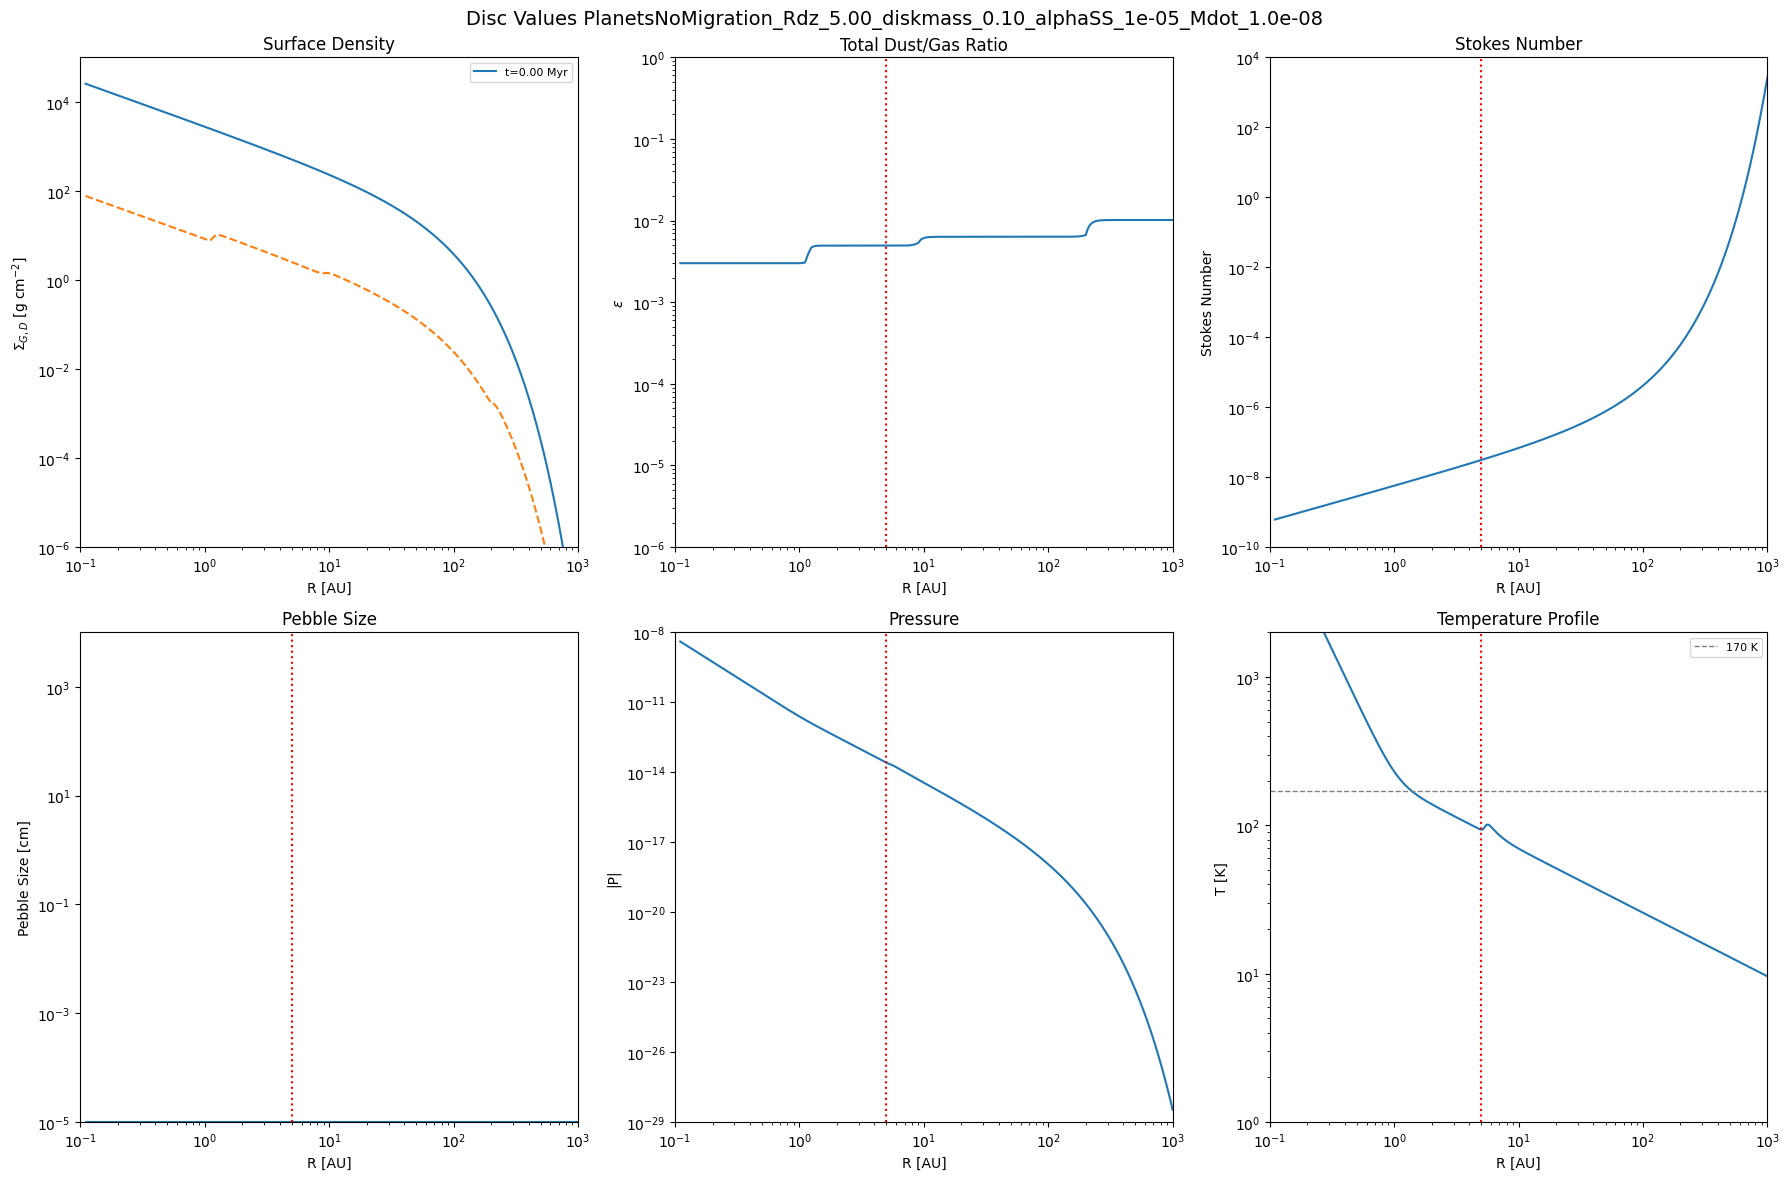

Saved: /Users/james/Documents/GitHub/DiscEvolution/james/may2026/output/CASCA_planets2/PlanetsNoMigration_Rdz_5.00_diskmass_0.10_alphaSS_1e-05_Mdot_1.0e-08/disc_values_1.png


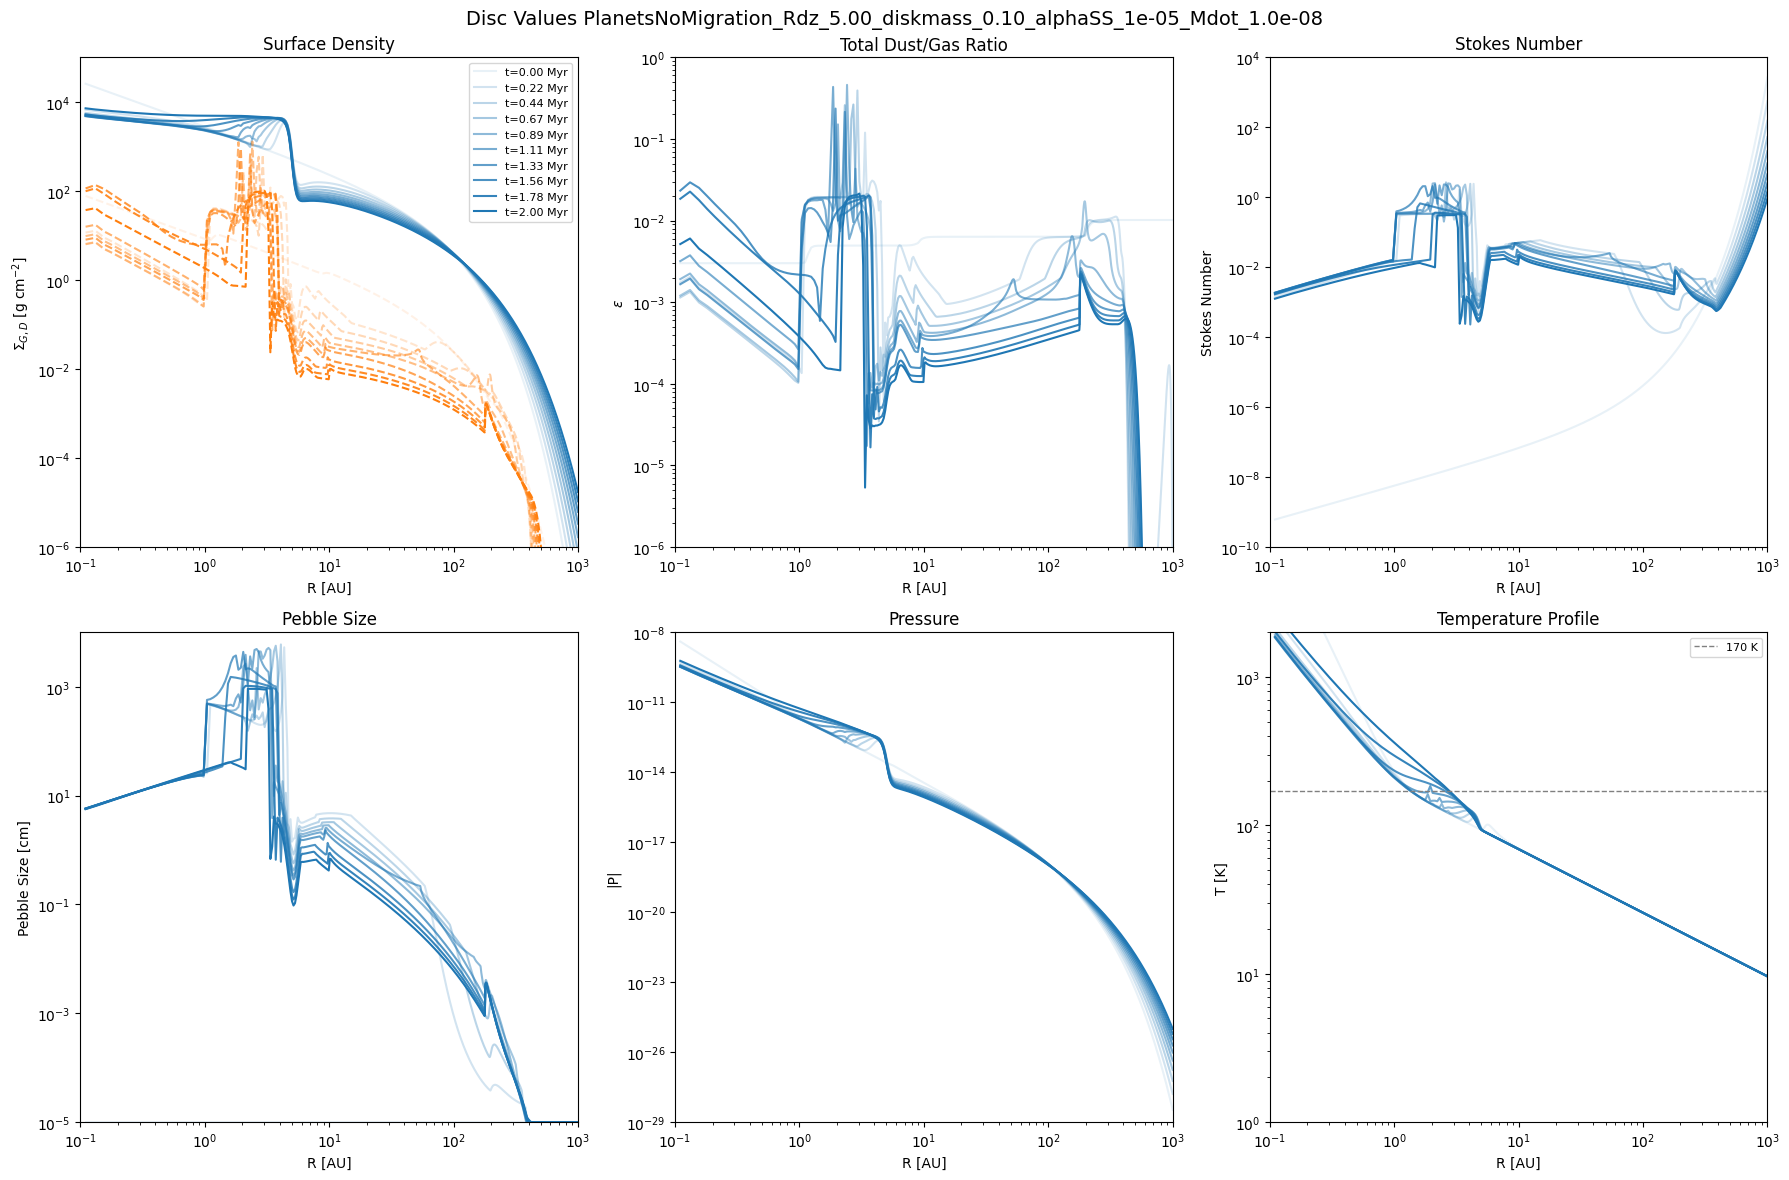

In [40]:
plot_disc_initial_values()
plot_disc_values()

# 13. Torque Maps

Saved: /Users/james/Documents/GitHub/DiscEvolution/james/may2026/output/CASCA_planets2/PlanetsNoMigration_Rdz_5.00_diskmass_0.10_alphaSS_1e-05_Mdot_1.0e-08/torque_maps.png


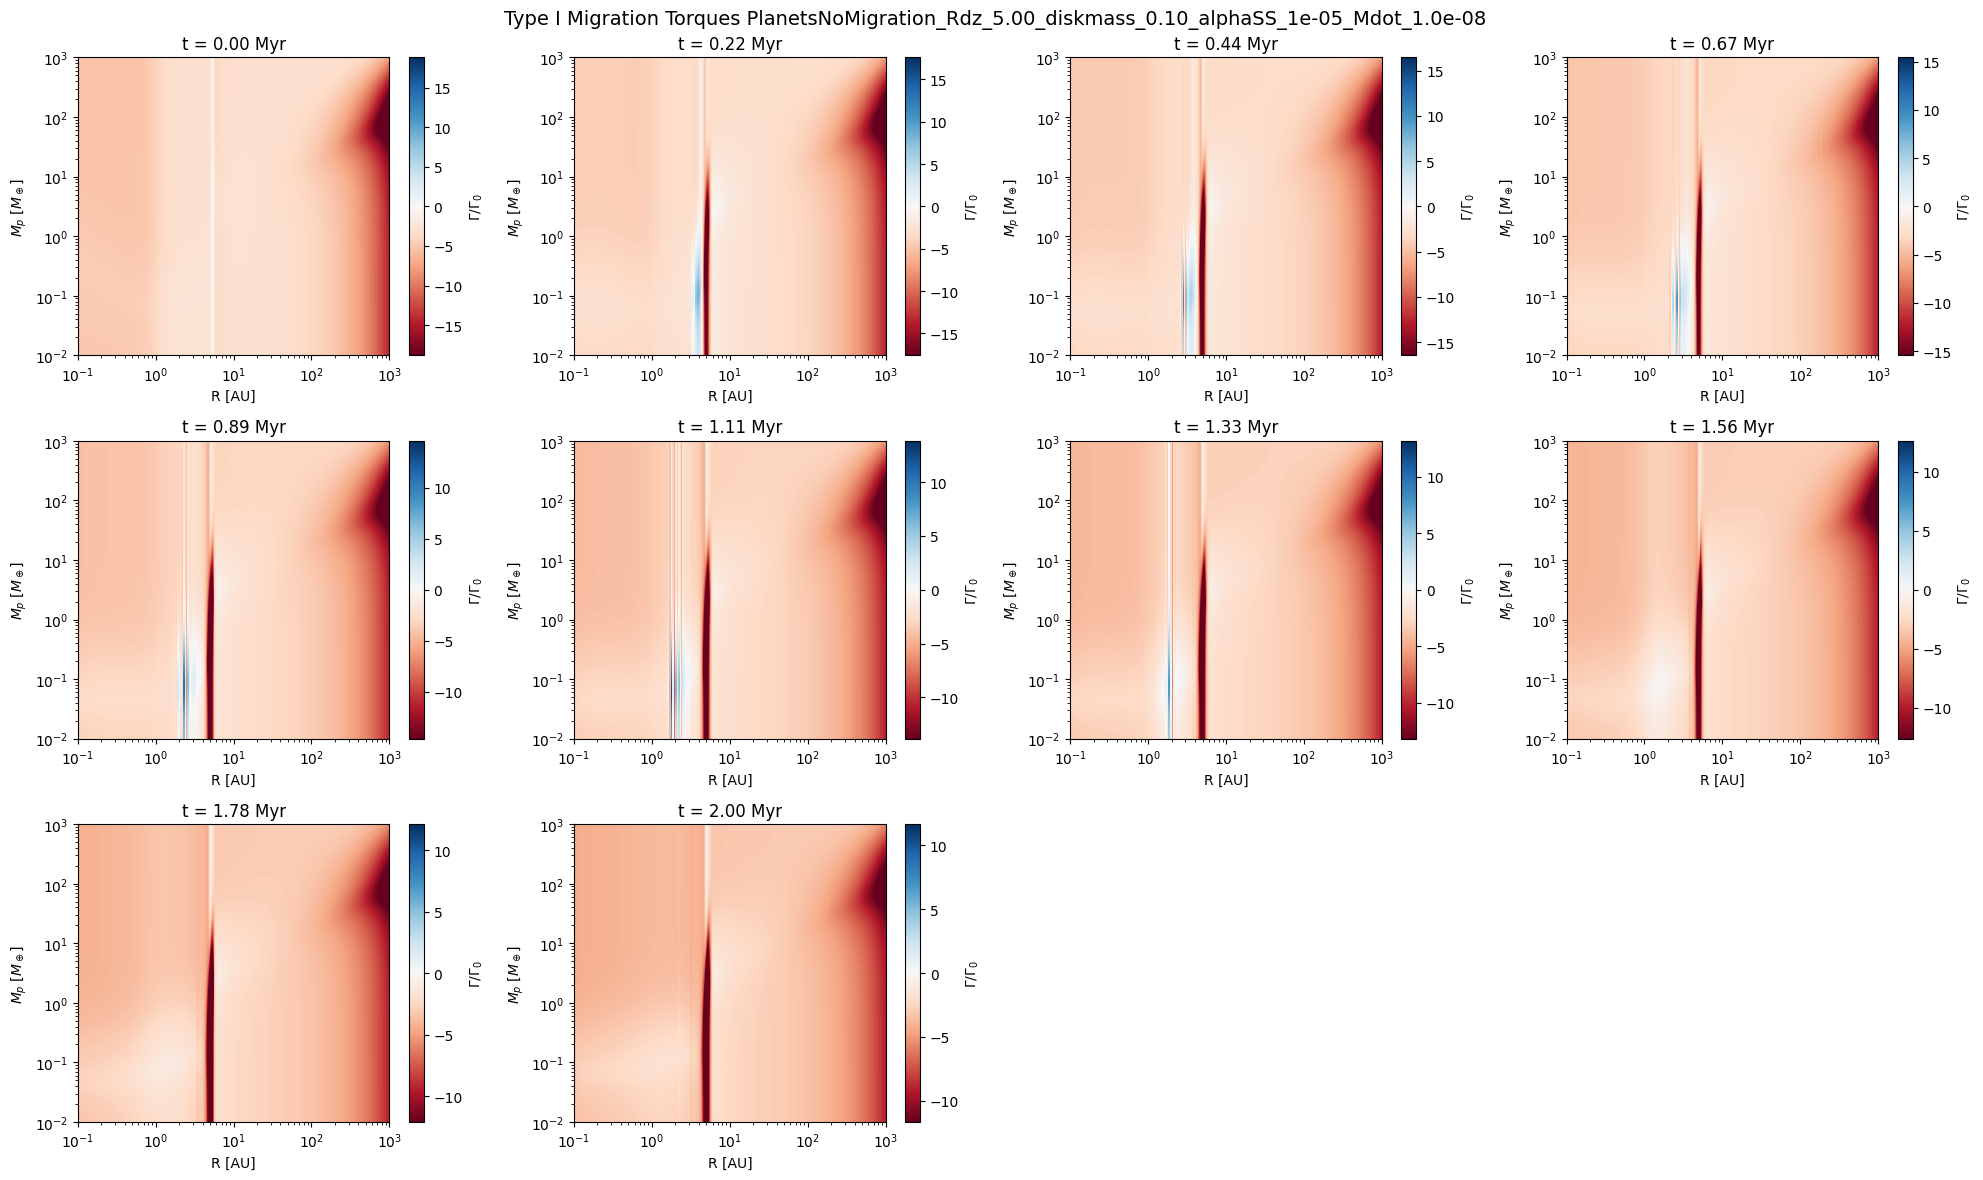

In [41]:

n_maps = len(torque_maps['maps'])
ncols = 4
nrows = int(np.ceil(n_maps / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4))
axes = np.atleast_2d(axes)

for idx in range(n_maps):
    ax = axes[idx // ncols, idx % ncols]
    T_map = torque_maps['maps'][idx]
    t_label = torque_maps['t_yr'][idx]

    # Symmetric colour scale around zero
    vmax = np.percentile(np.abs(T_map), 98) #drop top 2% of values to get less washed out look
    vmin = -vmax

    im = ax.pcolormesh(
        radius_array, mass_array, T_map,
        cmap='RdBu',        # red = inward (negative), blue = outward (positive)
        vmin=vmin, vmax=vmax,
        shading='auto'
    )

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('R [AU]')
    ax.set_ylabel(r'$M_p$ [$M_\oplus$]')
    ax.set_title(f't = {t_label/1e6:.2f} Myr')
    ax.set_xlim(R_in, R_out)
    fig.colorbar(im, ax=ax, label=r'$\Gamma / \Gamma_0$')

# Hide unused axes
for idx in range(n_maps, nrows * ncols):
    axes[idx // ncols, idx % ncols].set_visible(False)

plt.suptitle('Type I Migration Torques '+subfolder, fontsize=14)
plt.tight_layout()
savefig('torque_maps.png', subfolder)
plt.show()


# 14. Accretion Rate Plot

Saved: /Users/james/Documents/GitHub/DiscEvolution/james/may2026/output/CASCA_planets2/PlanetsNoMigration_Rdz_5.00_diskmass_0.10_alphaSS_1e-05_Mdot_1.0e-08/Mdot_star.png


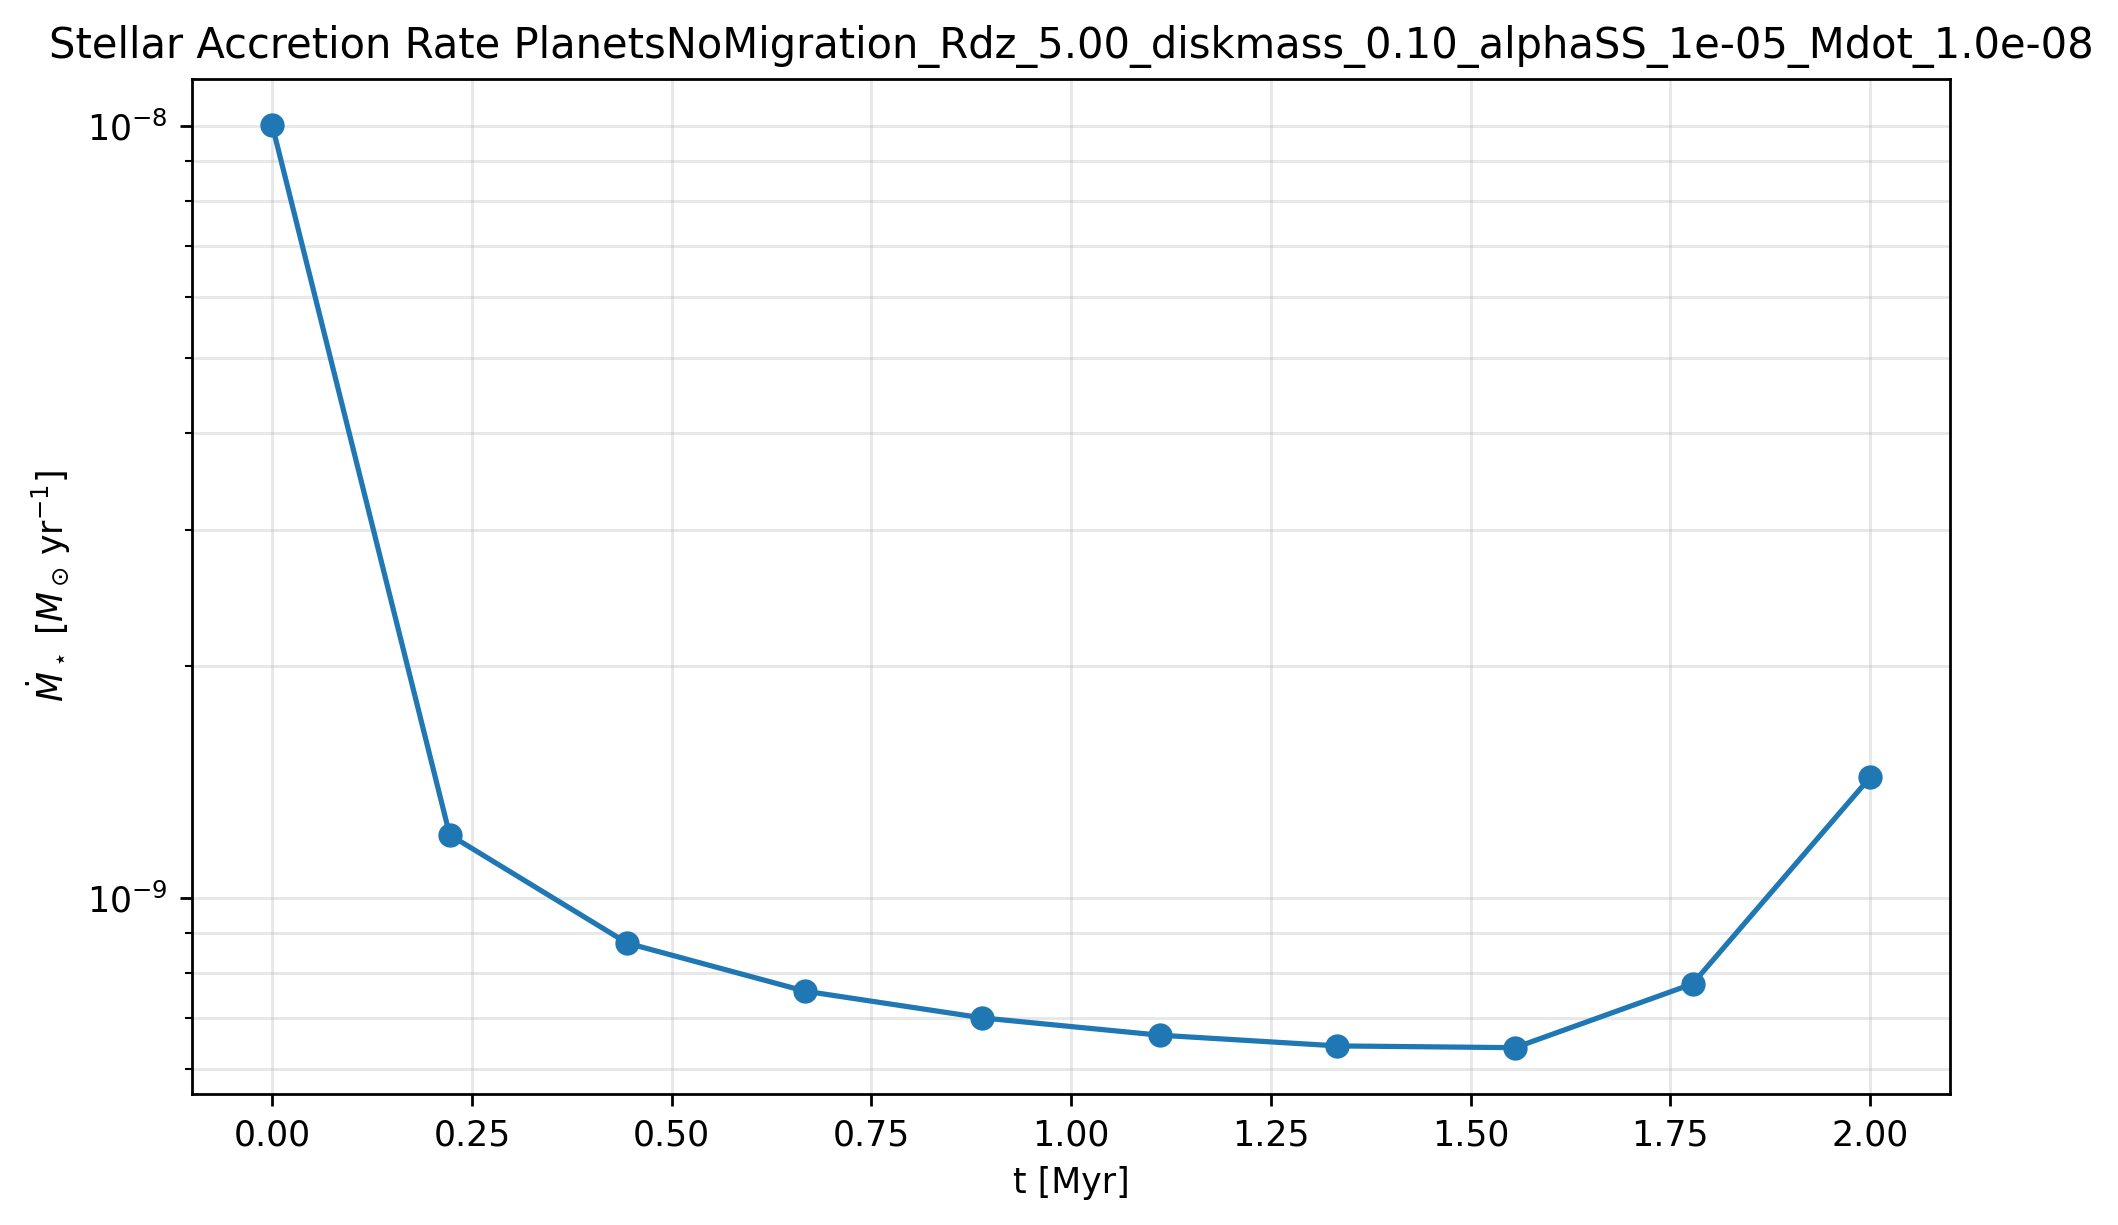

In [42]:
fig, ax = plt.subplots(figsize=(8, 5), dpi = 250)

ax.semilogy(np.array(history['t_yr']) / 1e6, np.array(history['Mdot_star']), 'o-', color='C0', lw=1.5)
ax.set_xlabel('t [Myr]')
ax.set_ylabel(r'$\dot{M}_\star$ [$M_\odot\,\mathrm{yr}^{-1}$]')
ax.set_title('Stellar Accretion Rate '+subfolder)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()

savefig('Mdot_star.png', subfolder) 
plt.show()

Saved: /Users/james/Documents/GitHub/DiscEvolution/james/may2026/output/CASCA_planets2/PlanetsNoMigration_Rdz_5.00_diskmass_0.10_alphaSS_1e-05_Mdot_1.0e-08/Mdot_r.png


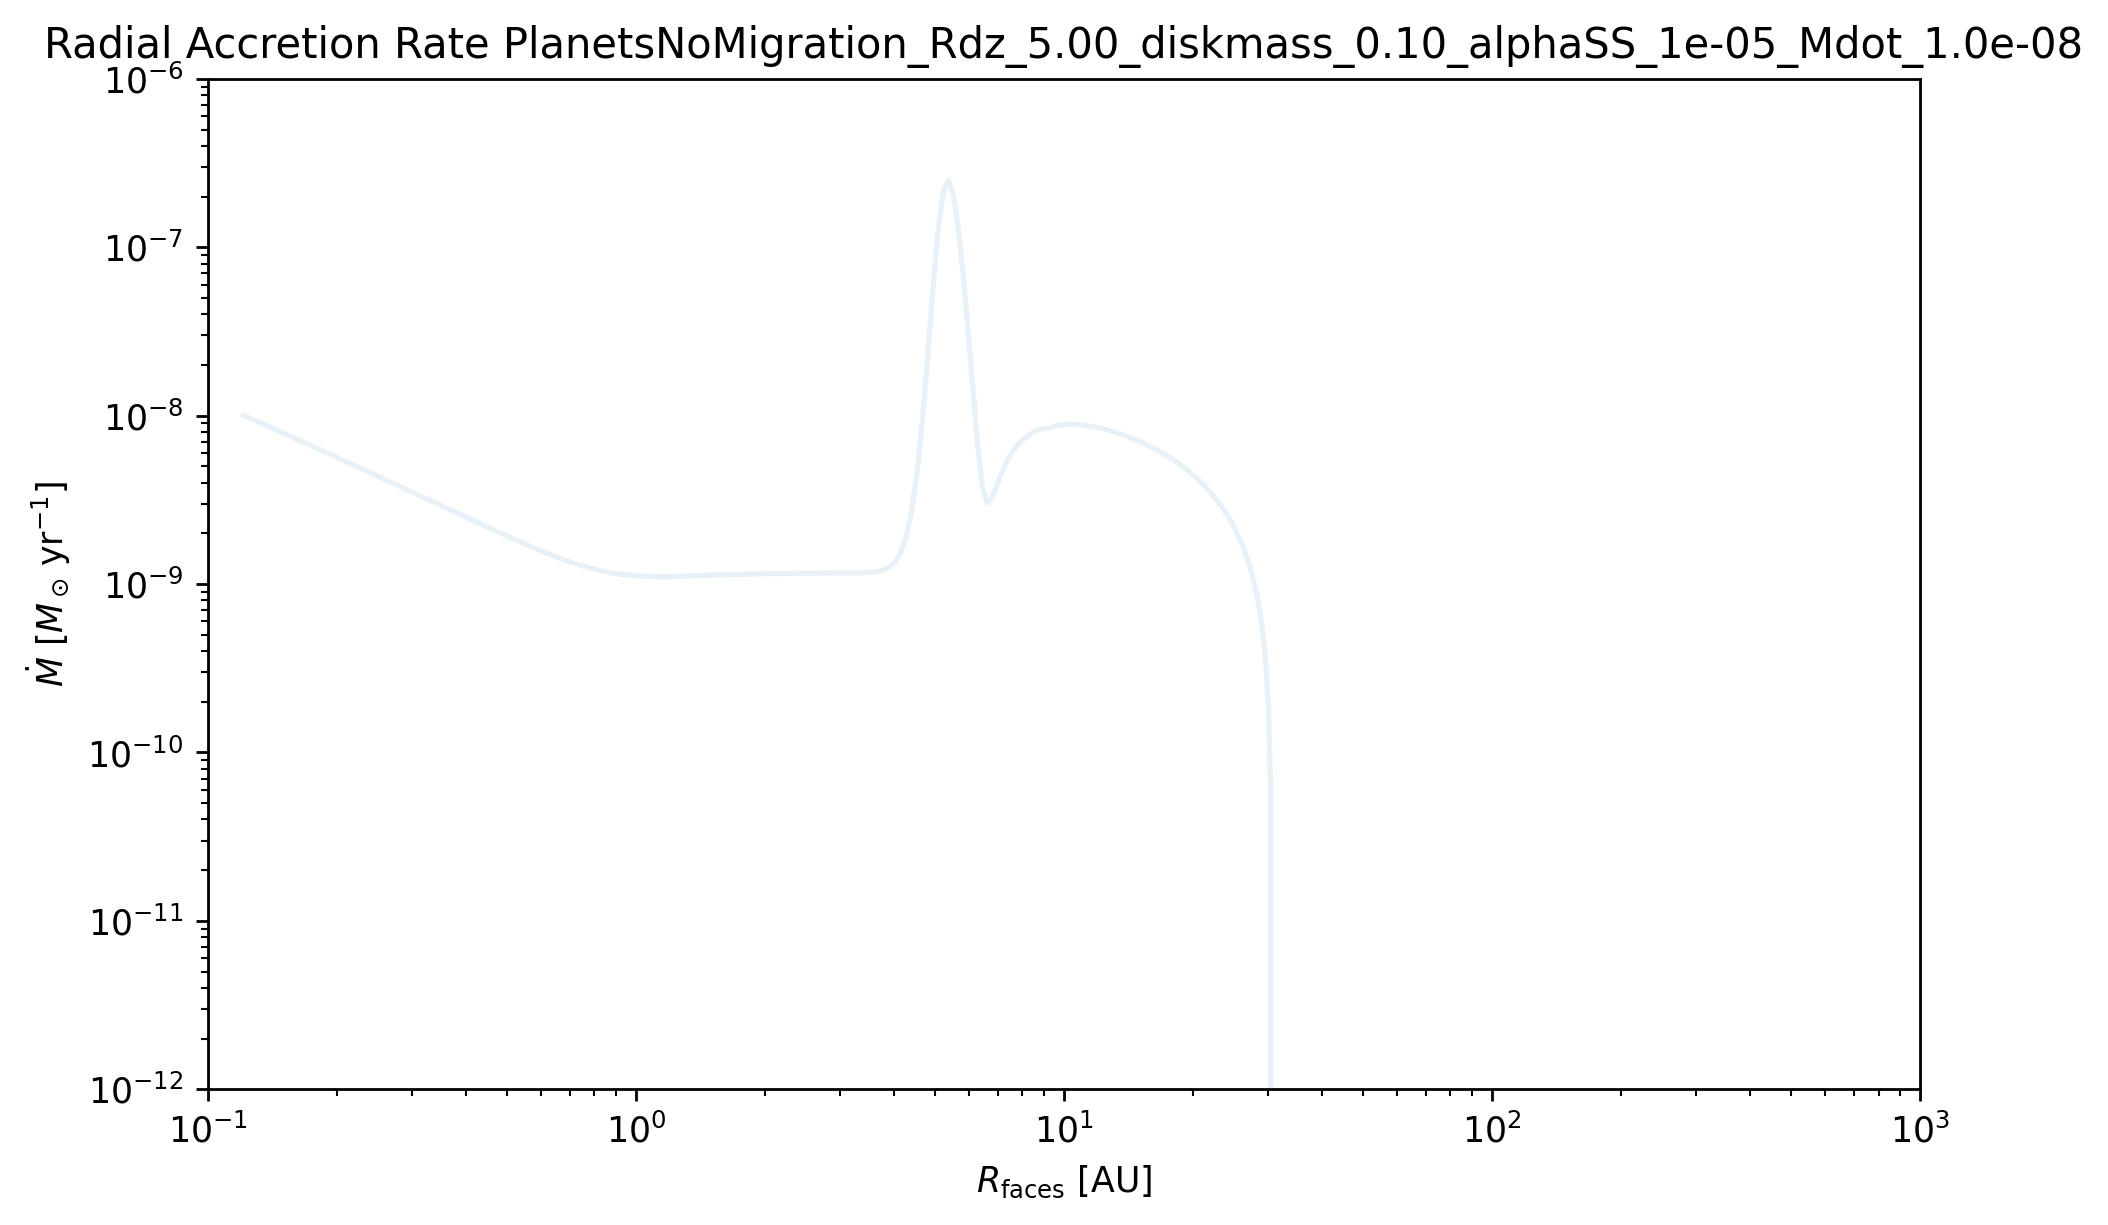

In [43]:
fig, ax = plt.subplots(figsize=(8, 5), dpi = 250)

n_snaps = len(history['t_yr'])
alphas = np.linspace(0.1, 1.0, max(n_snaps, 1))

# Remove this line: ax = axes[1, 0]

for i, line in enumerate(history['Mdot_r']):
    ax.loglog(history['R_faces'][i], history['Mdot_r'][i], linestyle='solid', color='C0', alpha=alphas[i],
                label=rf"t={history['t_yr'][i]/1e6:.2f} Myr", lw=1.5)
    if i > -1: 
        break

ax.set_xlabel(r'$R_{\rm faces}$ [AU]')
ax.set_ylabel(r'$\dot{M}$ [$M_\odot\,\mathrm{yr}^{-1}$]')
ax.set_title('Radial Accretion Rate '+subfolder)
ax.set_xlim(R_in, R_out)
# Filter for finite AND positive values (needed for log scale)
Mdot_r_flat = np.array(history['Mdot_r']).flatten()
Mdot_r_valid = Mdot_r_flat[(np.isfinite(Mdot_r_flat)) & (Mdot_r_flat > 0)]
if len(Mdot_r_valid) > 0:
    ax.set_ylim(10**(np.floor(np.log10(np.min(Mdot_r_valid)))), 10**(np.ceil(np.log10(np.max(Mdot_r_valid)))))
ax.minorticks_on()
ax.tick_params(axis='both', which='minor', length=2)
plt.tight_layout()
#ax.axvline(R_dz.value, ls = ':', color = 'red')

savefig('Mdot_r.png', subfolder)
plt.show()

In [44]:
history['Rc']

[]

In [45]:
# Diagnostic: Check Mdot_r values at different radii
print("=== Mdot_r Diagnostic ===")
print(f"\nFinal snapshot (t = {history['t_yr'][-1]/1e6:.2f} Myr):")
print(f"Mdot at star: {history['Mdot_star'][-1]:.3e} Msun/yr")

# Check values at different radii
R_faces_final = history['R_faces'][-1]
Mdot_r_final = history['Mdot_r'][-1]

# Find specific radii
idx_10 = np.argmin(np.abs(R_faces_final - 10))
idx_20 = np.argmin(np.abs(R_faces_final - 20))  # Dead zone boundary
idx_50 = np.argmin(np.abs(R_faces_final - 50))
idx_100 = np.argmin(np.abs(R_faces_final - 100))

print(f"\nMdot(R=~{R_faces_final[idx_10]:.1f} AU) = {Mdot_r_final[idx_10]:.3e} Msun/yr")
print(f"Mdot(R=~{R_faces_final[idx_20]:.1f} AU) = {Mdot_r_final[idx_20]:.3e} Msun/yr  <- Dead zone")
print(f"Mdot(R=~{R_faces_final[idx_50]:.1f} AU) = {Mdot_r_final[idx_50]:.3e} Msun/yr")
print(f"Mdot(R=~{R_faces_final[idx_100]:.1f} AU) = {Mdot_r_final[idx_100]:.3e} Msun/yr")

# Check for negative values (outward flow)
n_negative = np.sum(Mdot_r_final < 0)
print(f"\n{n_negative} radii have negative Mdot (outward flow)")
if n_negative > 0:
    neg_mask = Mdot_r_final < 0
    print(f"Negative Mdot range: R = {R_faces_final[neg_mask].min():.1f} to {R_faces_final[neg_mask].max():.1f} AU")
    print(f"Most negative: {Mdot_r_final[neg_mask].min():.3e} Msun/yr at R = {R_faces_final[np.argmin(Mdot_r_final)]:.1f} AU")

# Check Sigma at outer edge
print(f"\nSurface density at R=100 AU: {disc.Sigma[np.argmin(np.abs(disc.R - 100))]:.3e} g/cm^2")
print(f"Disc outer radius (Rout): {history['Rout'][-1]:.1f} AU")
#print(f"Disc characteristic radius (Rc): {history['Rc'][-1]:.1f} AU")

=== Mdot_r Diagnostic ===

Final snapshot (t = 2.00 Myr):
Mdot at star: 1.433e-09 Msun/yr

Mdot(R=~10.0 AU) = 7.046e-09 Msun/yr
Mdot(R=~20.1 AU) = 5.468e-09 Msun/yr  <- Dead zone
Mdot(R=~50.1 AU) = 1.146e-09 Msun/yr
Mdot(R=~99.8 AU) = -2.217e-09 Msun/yr

759 radii have negative Mdot (outward flow)
Negative Mdot range: R = 61.8 to 998.0 AU
Most negative: -2.863e-09 Msun/yr at R = 147.6 AU

Surface density at R=100 AU: 3.524e+00 g/cm^2
Disc outer radius (Rout): 1000.0 AU


Saved: /Users/james/Documents/GitHub/DiscEvolution/james/may2026/output/CASCA_planets2/PlanetsNoMigration_Rdz_5.00_diskmass_0.10_alphaSS_1e-05_Mdot_1.0e-08/Mdot_r_absolute.png


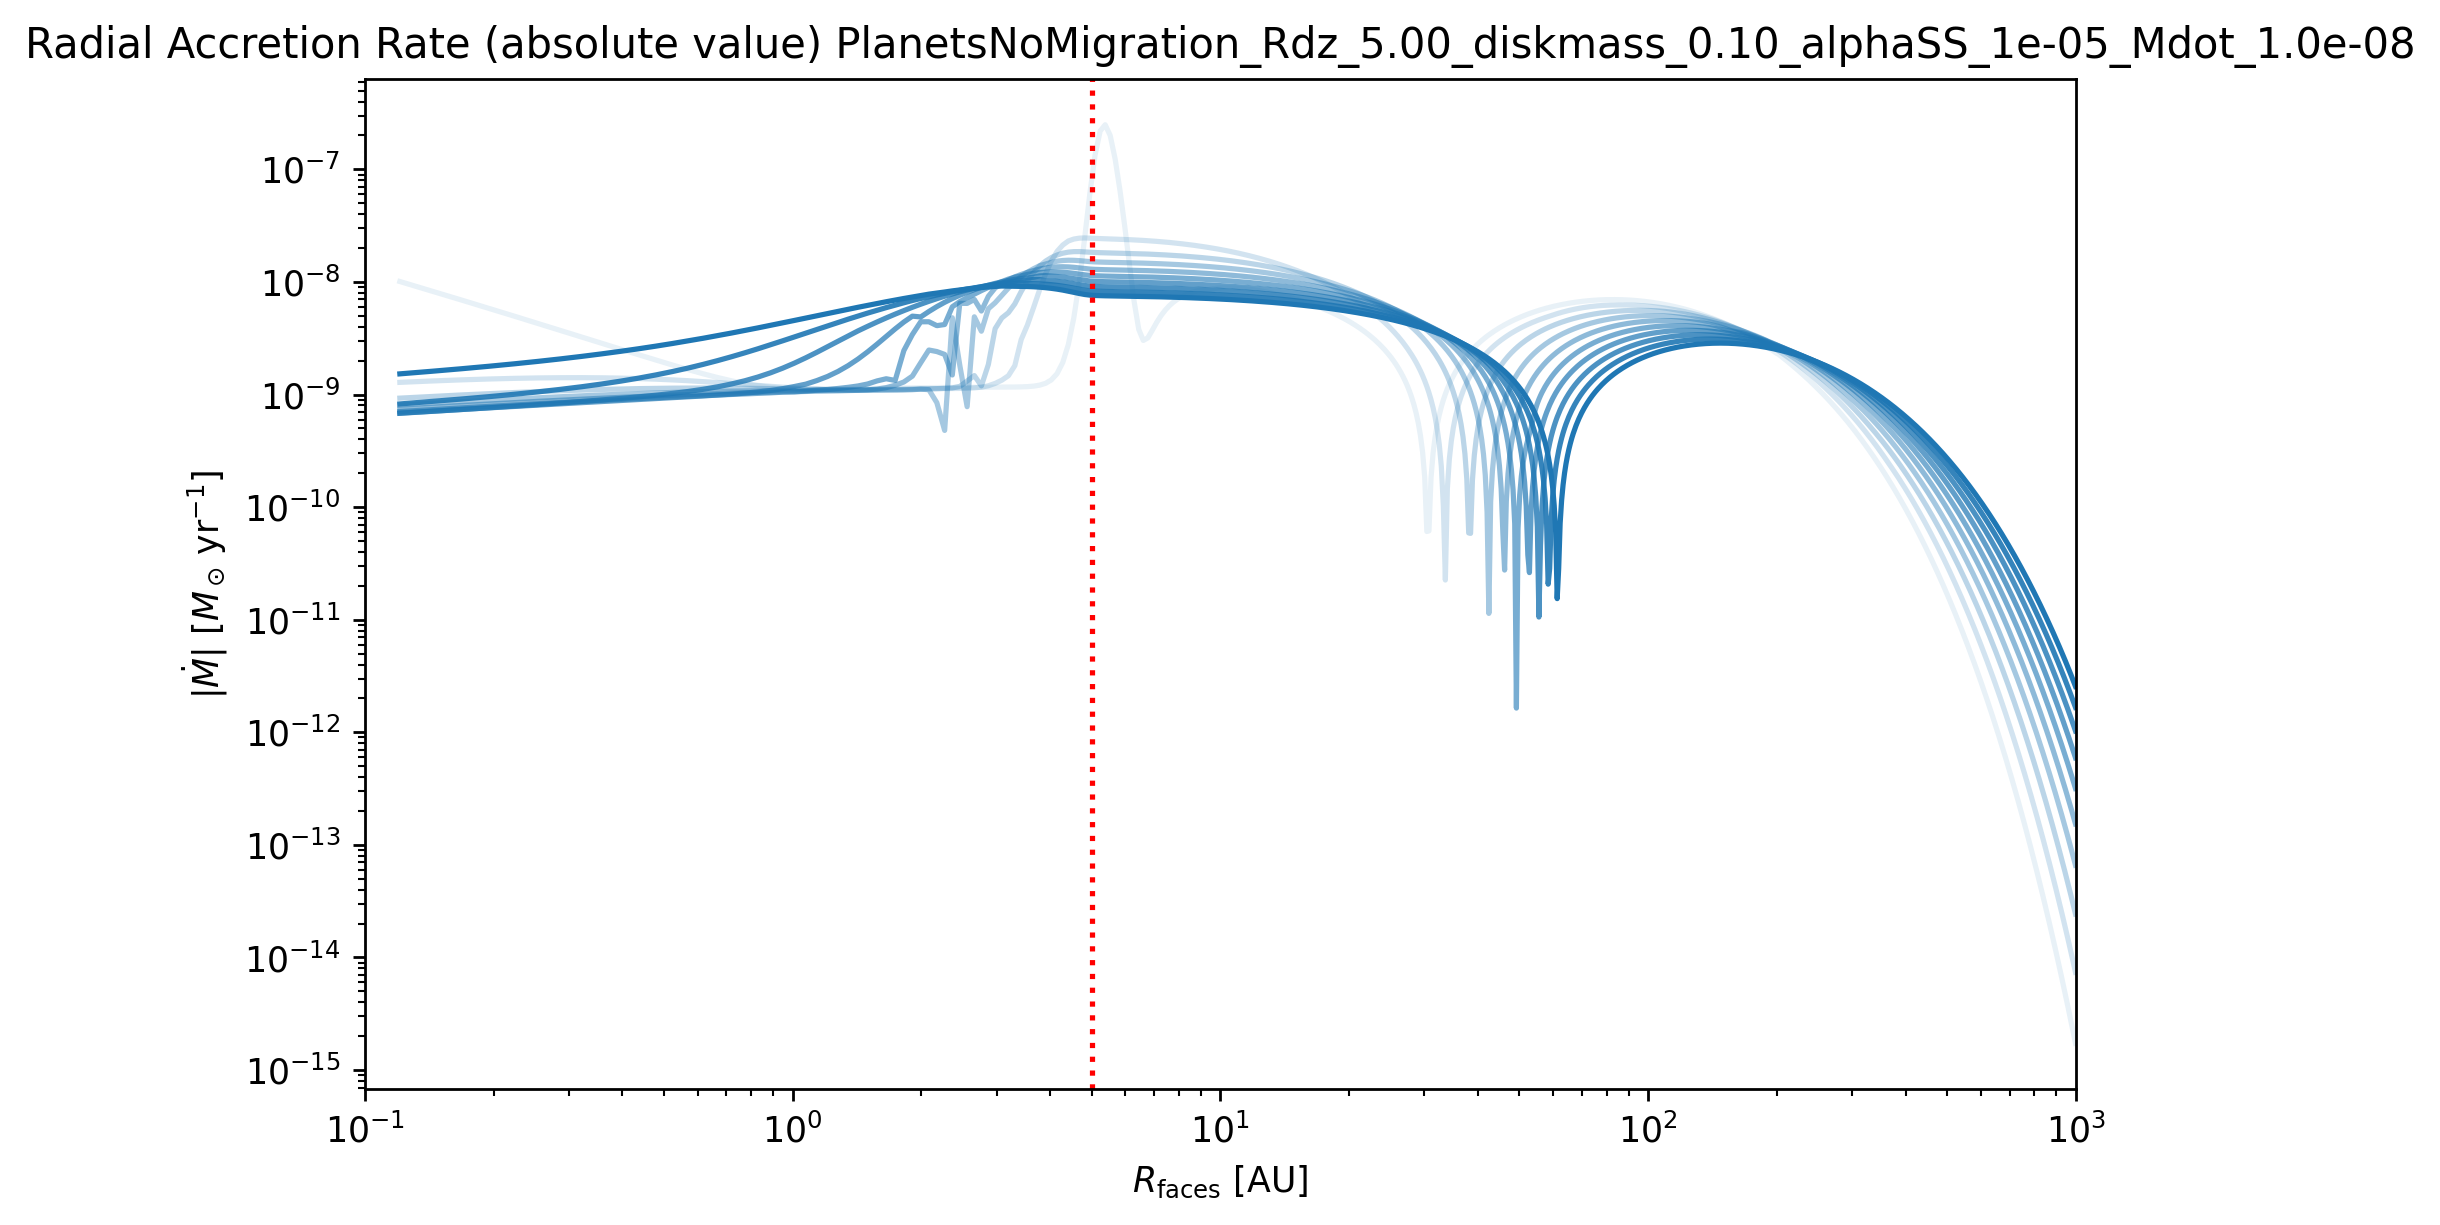

In [46]:
# Better visualization showing both inward (positive) and outward (negative) flow
fig, ax = plt.subplots(figsize=(8, 5), dpi=250)

n_snaps = len(history['t_yr'])
alphas = np.linspace(0.1, 1.0, max(n_snaps, 1))

for i in range(len(history['Mdot_r'])):
    R = history['R_faces'][i]
    Mdot = history['Mdot_r'][i]
    
    # Plot absolute value on log scale, with color indicating direction #TODO: color indicating direction?
    ax.loglog(R, np.abs(Mdot), linestyle='solid', color='C0', alpha=alphas[i], lw=1.5)

ax.set_xlabel(r'$R_{\rm faces}$ [AU]')
ax.set_ylabel(r'$|\dot{M}|$ [$M_\odot\,\mathrm{yr}^{-1}$]')
ax.set_title('Radial Accretion Rate (absolute value) '+subfolder)
ax.set_xlim(R_in, R_out)
ax.minorticks_on()
ax.tick_params(axis='both', which='minor', length=2)
plt.tight_layout()
ax.axvline(R_dz.value, ls = ':', color = 'red')

savefig('Mdot_r_absolute.png', subfolder)
plt.show()

Saved: /Users/james/Documents/GitHub/DiscEvolution/james/may2026/output/CASCA_planets2/PlanetsNoMigration_Rdz_5.00_diskmass_0.10_alphaSS_1e-05_Mdot_1.0e-08/Mdot_r_signed.png


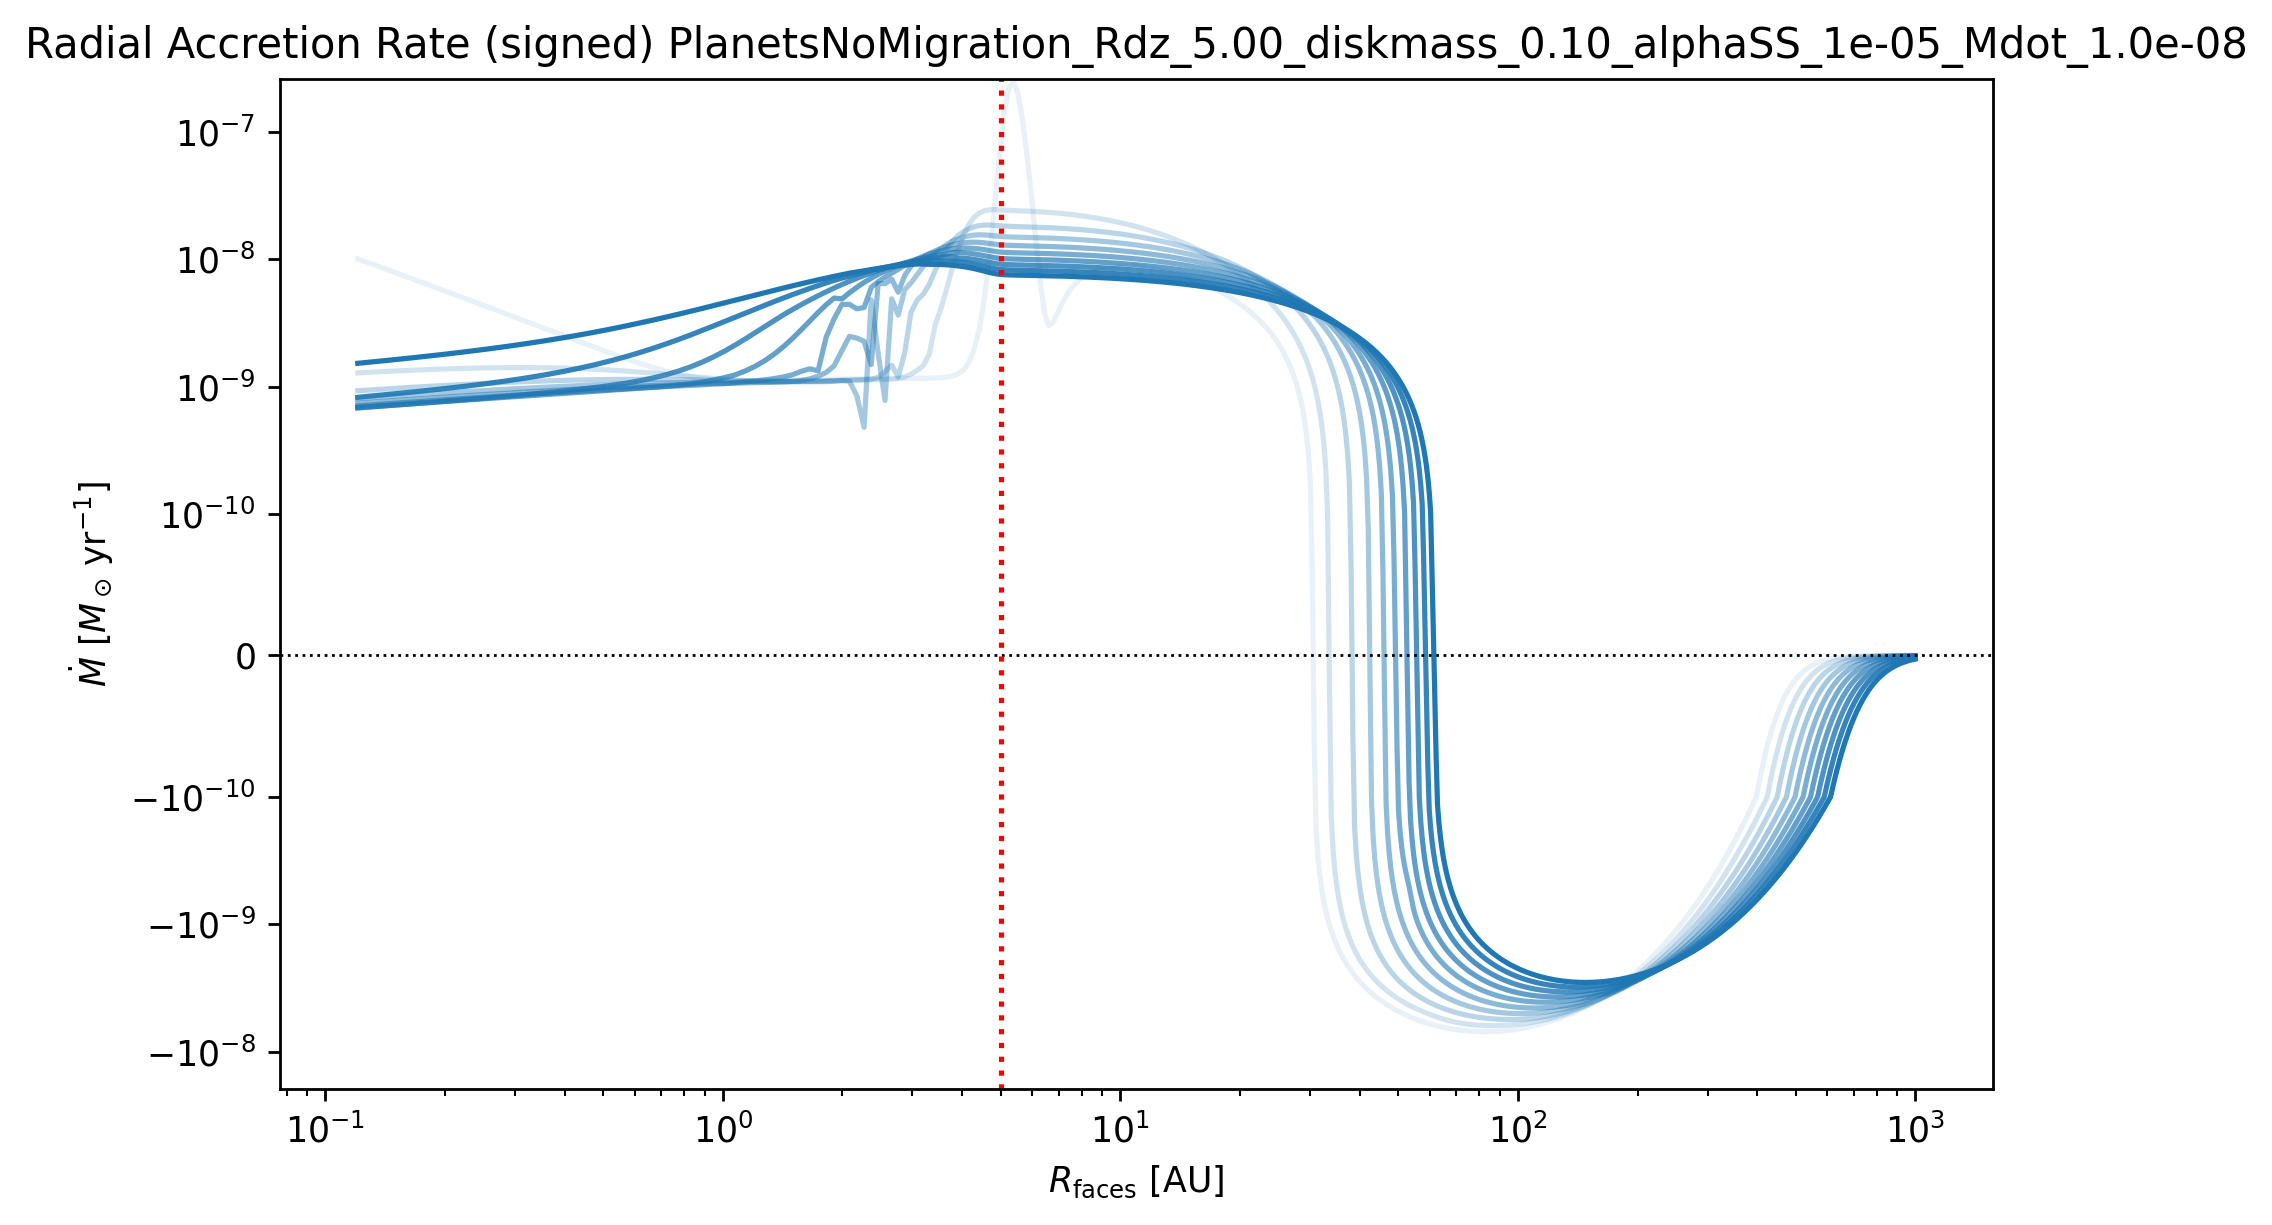

In [47]:
# Alternative: signed plot with symlog scale (shows both positive and negative)
fig, ax = plt.subplots(figsize=(8, 5), dpi=250)

n_snaps = len(history['t_yr'])
alphas = np.linspace(0.1, 1.0, max(n_snaps, 1))

for i in range(len(history['Mdot_r'])):
    ax.semilogx(history['R_faces'][i], history['Mdot_r'][i], 
                linestyle='solid', color='C0', alpha=alphas[i], lw=1.5)

ax.axhline(0, color='k', linestyle=':', lw=0.8, label='Zero (transition)')
ax.set_xlabel(r'$R_{\rm faces}$ [AU]')
ax.set_ylabel(r'$\dot{M}$ [$M_\odot\,\mathrm{yr}^{-1}$]')
ax.set_title('Radial Accretion Rate (signed) '+subfolder)
#ax.set_xlim(1, 10)
ax.set_yscale('symlog', linthresh=1e-10)  # Symmetric log scale
ax.minorticks_on()
ax.tick_params(axis='both', which='minor', length=2)
plt.tight_layout()
ax.axvline(R_dz.value, ls = ':', color = 'red')

savefig('Mdot_r_signed.png', subfolder)
plt.show()

# 15. Dead Zone Transition Analysis

Saved: /Users/james/Documents/GitHub/DiscEvolution/james/may2026/output/CASCA_planets2/PlanetsNoMigration_Rdz_5.00_diskmass_0.10_alphaSS_1e-05_Mdot_1.0e-08/deadzone_analysis.png


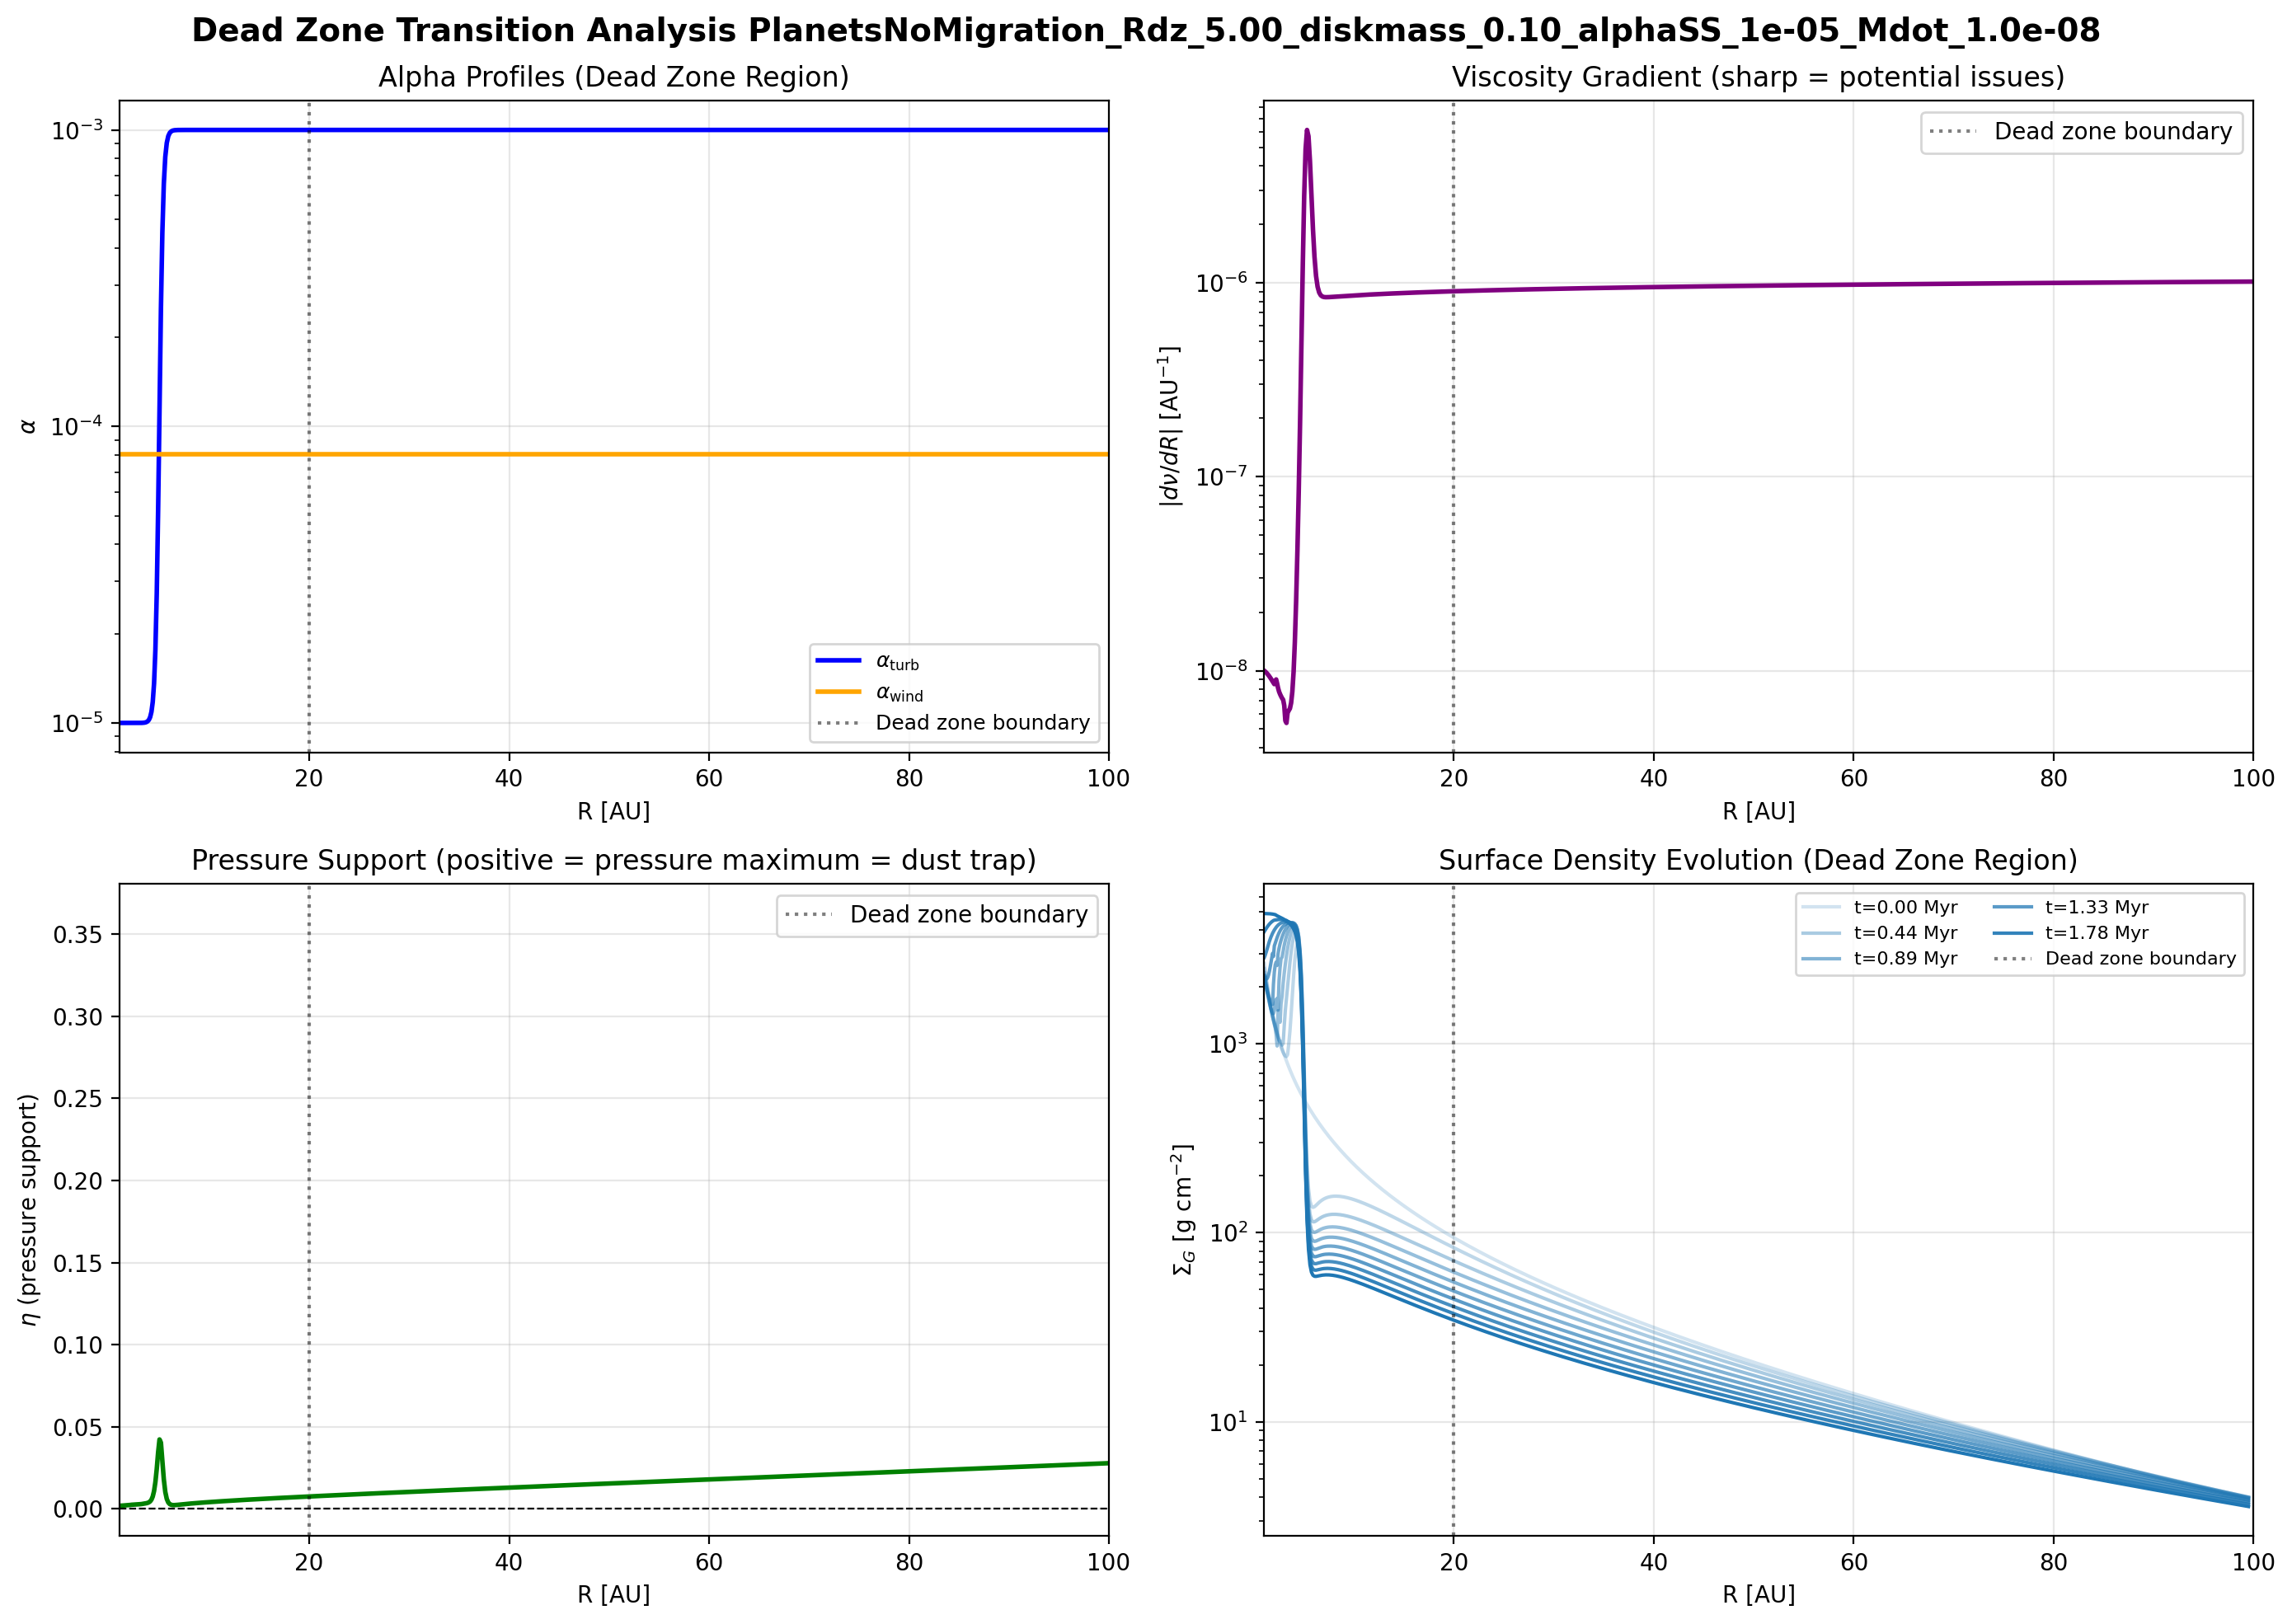

=== DEAD ZONE DIAGNOSTICS ===

Viscosity jump at R=20 AU:
  α_SS(19 AU) = 1.000e-03
  α_SS(21 AU) = 1.000e-03
  Jump factor: 1.0x

Pressure maximum:
  Location: R = 999.0 AU
  η_max = 3.624e-01
  ⚠️ POSITIVE η = pressure maximum = dust trap!

Surface density at dead zone boundary:
  Σ(15 AU) = 4.38e+01 g/cm²
  Σ(20 AU) = 3.46e+01 g/cm²
  Σ(25 AU) = 2.78e+01 g/cm²


In [48]:
# Analyze the dead zone transition to understand the Mdot spike and Sigma drop
fig, axes = plt.subplots(2, 2, figsize=(14, 10), dpi=200)

# Focus on the dead zone region (1-100 AU)
R_focus_mask = (disc.R > 1) & (disc.R < 100)
R_focus = disc.R[R_focus_mask]

# 1. Alpha profiles zoomed in
ax = axes[0, 0]
ax.semilogy(Rgrid, alpha_SS_arr, label=r'$\alpha_{\rm turb}$', lw=2, color='blue')
ax.semilogy(Rgrid, psi_arr * alpha_SS_arr, label=r'$\alpha_{\rm wind}$', lw=2, color='orange')
#ax.semilogy(Rgrid, alpha_eff_arr, label=r'$\alpha_{\rm eff}$', lw=2, color='red', ls='--')
ax.axvline(20, color='k', ls=':', alpha=0.5, label='Dead zone boundary')
ax.set_xlabel('R [AU]')
ax.set_ylabel(r'$\alpha$')
ax.set_title('Alpha Profiles (Dead Zone Region)')
ax.set_xlim(1, 100)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# 2. Viscosity gradient (dν/dr)
ax = axes[0, 1]
nu = eos.nu  # viscosity from final state
dnu_dR = np.gradient(nu, disc.R)  # gradient
ax.semilogy(disc.R, np.abs(dnu_dR), lw=2, color='purple')
ax.axvline(20, color='k', ls=':', alpha=0.5, label='Dead zone boundary')
ax.set_xlabel('R [AU]')
ax.set_ylabel(r'$|d\nu/dR|$ [AU$^{-1}$]')
ax.set_title('Viscosity Gradient (sharp = potential issues)')
ax.set_xlim(1, 100)
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Pressure gradient (for dust trapping)
ax = axes[1, 0]
P_final = history['P'][-1]
dP_dR = np.gradient(P_final, disc.R)
OmegaK_arr = np.sqrt(const.G.cgs.value * star.M * Msun / (disc.R * AU)**3)  # Keplerian angular velocity
eta = -0.5 * (dP_dR / disc.midplane_gas_density) / (disc.R * AU * OmegaK_arr**2)  # pressure support parameter
ax.plot(disc.R, eta, lw=2, color='green')
ax.axhline(0, color='k', ls='--', lw=0.8)
ax.axvline(20, color='k', ls=':', alpha=0.5, label='Dead zone boundary')
ax.set_xlabel('R [AU]')
ax.set_ylabel(r'$\eta$ (pressure support)')
ax.set_title('Pressure Support (positive = pressure maximum = dust trap)')
ax.set_xlim(1, 100)
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Surface density evolution at the dead zone
ax = axes[1, 1]
for i, t_snap in enumerate(history['t_yr']):
    alpha_time = np.linspace(0.2, 1.0, len(history['t_yr']))[i]
    ax.semilogy(disc.R[R_focus_mask], history['Sigma_G'][i][R_focus_mask], 
                color='C0', alpha=alpha_time, lw=1.5, 
                label=f't={t_snap/1e6:.2f} Myr' if i % 2 == 0 else '')
ax.axvline(20, color='k', ls=':', alpha=0.5, label='Dead zone boundary')
ax.set_xlabel('R [AU]')
ax.set_ylabel(r'$\Sigma_G$ [g cm$^{-2}$]')
ax.set_title('Surface Density Evolution (Dead Zone Region)')
ax.set_xlim(1, 100)
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)

plt.suptitle('Dead Zone Transition Analysis '+subfolder, fontsize=14, fontweight='bold')
plt.tight_layout()
savefig('deadzone_analysis.png', subfolder)
plt.show()

# Print diagnostics
print("=== DEAD ZONE DIAGNOSTICS ===")
print(f"\nViscosity jump at R=20 AU:")
idx_19 = np.argmin(np.abs(disc.R - 19))
idx_21 = np.argmin(np.abs(disc.R - 21))
print(f"  α_SS(19 AU) = {alpha_SS_arr[idx_19]:.3e}")
print(f"  α_SS(21 AU) = {alpha_SS_arr[idx_21]:.3e}")
print(f"  Jump factor: {alpha_SS_arr[idx_21]/alpha_SS_arr[idx_19]:.1f}x")

print(f"\nPressure maximum:")
idx_pmax = np.argmax(eta)
print(f"  Location: R = {disc.R[idx_pmax]:.1f} AU")
print(f"  η_max = {eta[idx_pmax]:.3e}")
if eta[idx_pmax] > 0:
    print(f"  ⚠️ POSITIVE η = pressure maximum = dust trap!")

print(f"\nSurface density at dead zone boundary:")
idx_20 = np.argmin(np.abs(disc.R - 20))
print(f"  Σ(15 AU) = {history['Sigma_G'][-1][np.argmin(np.abs(disc.R - 15))]:.2e} g/cm²")
print(f"  Σ(20 AU) = {history['Sigma_G'][-1][idx_20]:.2e} g/cm²")
print(f"  Σ(25 AU) = {history['Sigma_G'][-1][np.argmin(np.abs(disc.R - 25))]:.2e} g/cm²")

# 16. Planet Growth Tracks

In [55]:
history['planets_R']

[array([], dtype=float32),
 array([5.]),
 array([5.]),
 array([5.]),
 array([5.]),
 array([5.]),
 array([5.]),
 array([5.]),
 array([5.]),
 array([5.])]

In [56]:
history['planets_Mcore']

[array([], dtype=float32),
 array([10.00636575]),
 array([10.00636575]),
 array([10.00636575]),
 array([10.00636575]),
 array([10.00636575]),
 array([10.00636575]),
 array([10.00636575]),
 array([10.00636575]),
 array([10.00636575])]

In [57]:
history['planets_Menv']

[array([], dtype=float32),
 array([9.53335181]),
 array([1207.48572785]),
 array([2223.25898973]),
 array([3080.57648322]),
 array([3825.93049121]),
 array([4485.66791819]),
 array([5077.87352343]),
 array([5613.60862576]),
 array([6102.24207411])]

Saved: /Users/james/Documents/GitHub/DiscEvolution/james/may2026/output/CASCA_planets2/PlanetsNoMigration_Rdz_5.00_diskmass_0.10_alphaSS_1e-05_Mdot_1.0e-08/planet_MR_tracks.png


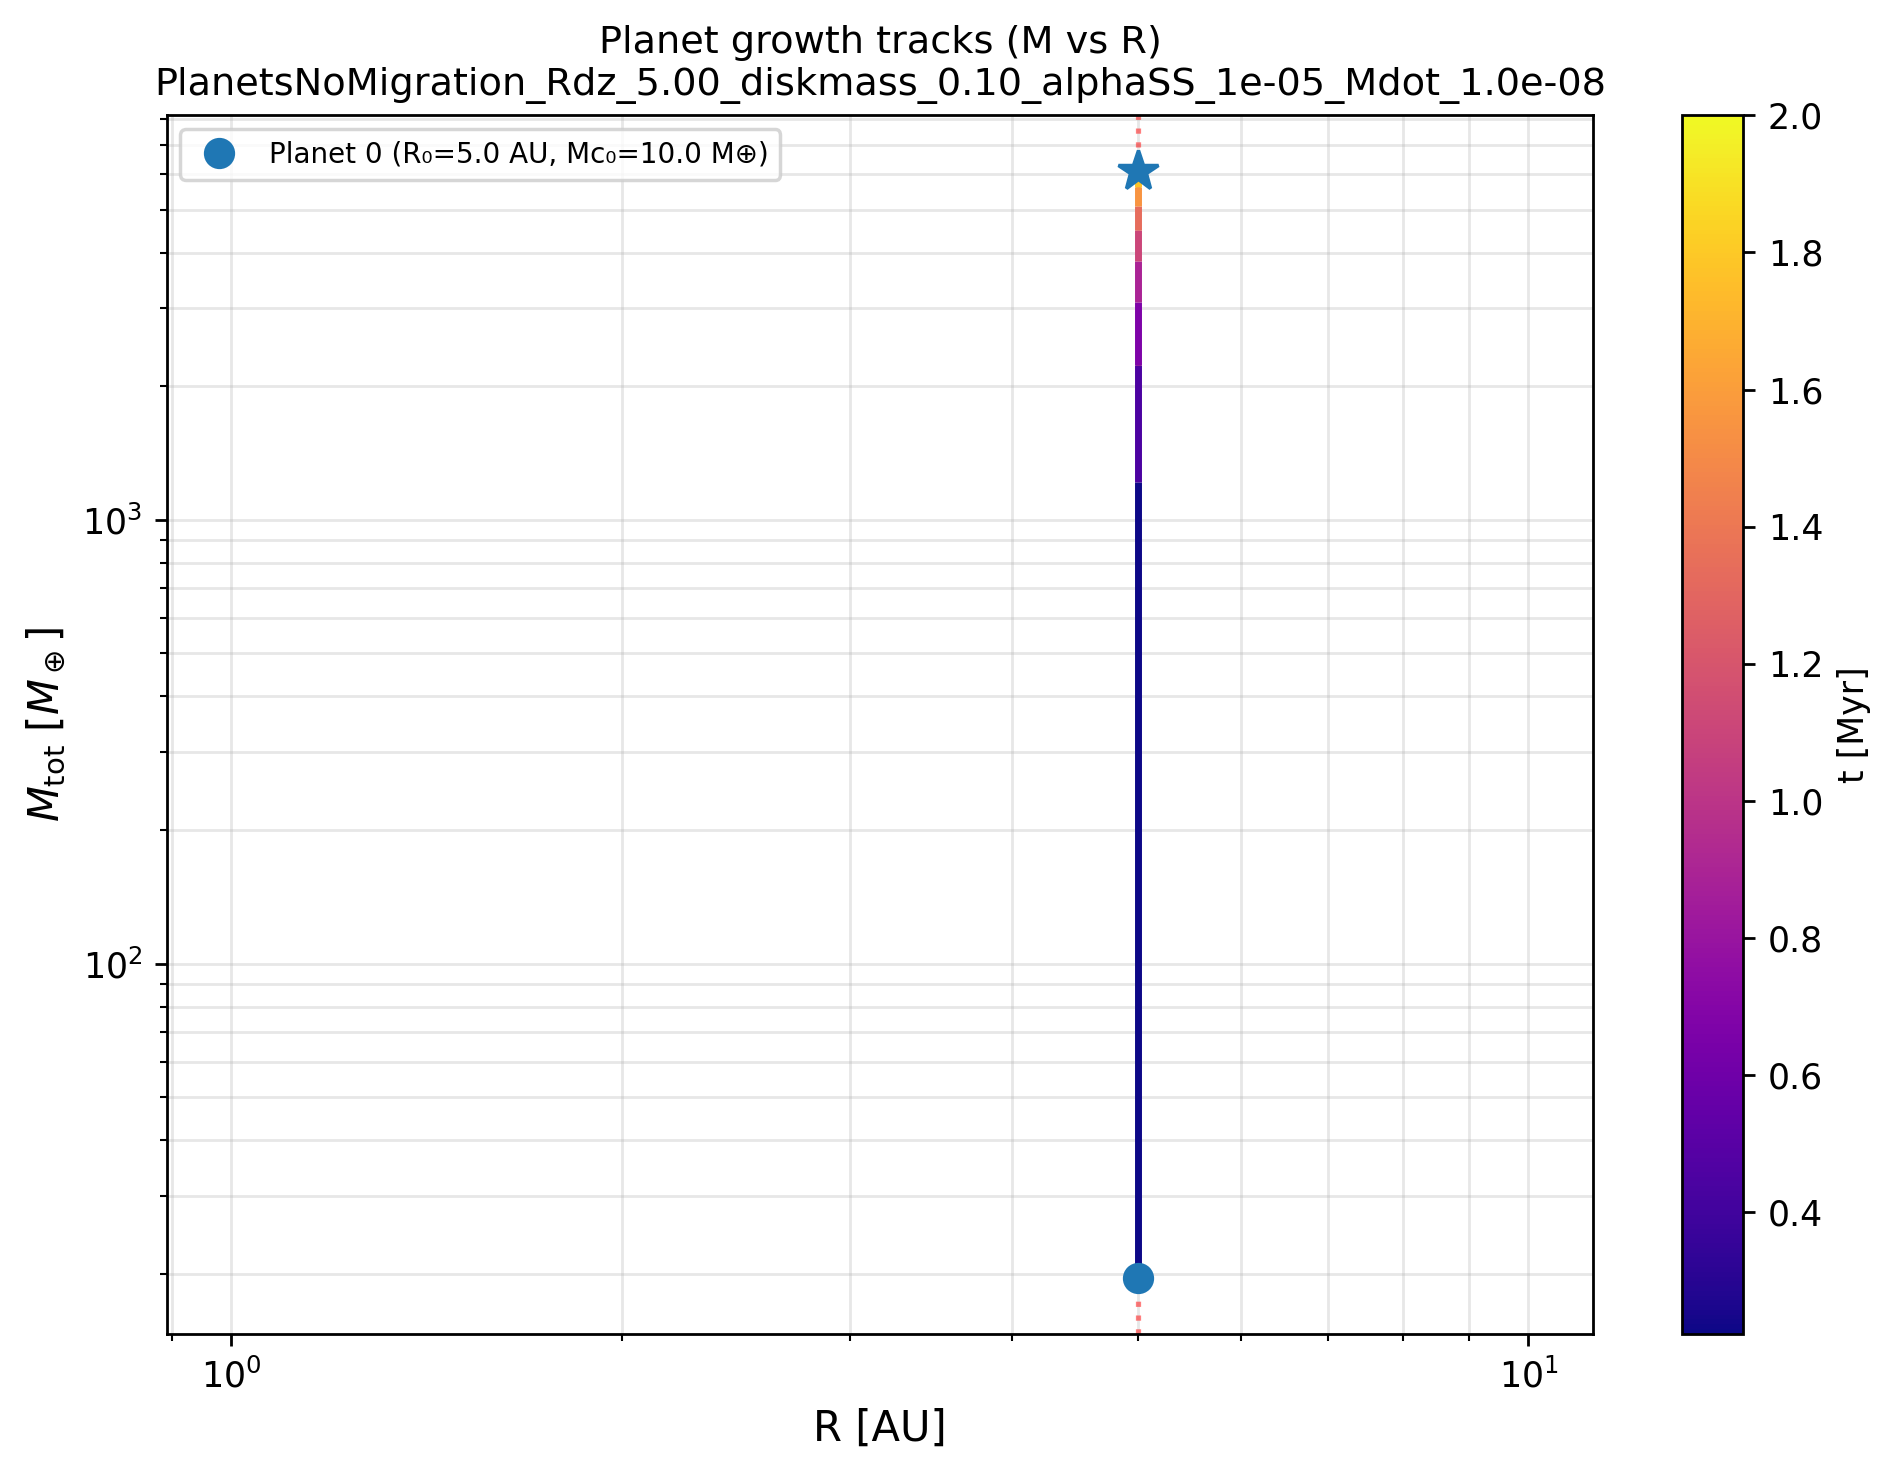

In [54]:
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import matplotlib.cm as cm

fig, ax = plt.subplots(figsize=(8, 6), dpi=250)

# Find first snapshot that actually has planets
first_snap = next(
    (s for s in range(len(history['planets_R'])) if len(history['planets_R'][s]) > 0),
    None
)

if first_snap is None:
    print("No planets found in history.")
else:
    planet_snaps = range(first_snap, len(history['t_yr']))
    t_snaps = np.array(history['t_yr'][first_snap:]) / 1e6  # Myr
    n_planets = len(history['planets_R'][first_snap])
    colors = plt.cm.tab10(np.linspace(0, 1, max(n_planets, 1)))

    norm = Normalize(vmin=t_snaps[0], vmax=t_snaps[-1])

    for i in range(n_planets):
        R_track     = np.array([history['planets_R'][s][i]     for s in planet_snaps])
        Mcore_track = np.array([history['planets_Mcore'][s][i] for s in planet_snaps])
        Menv_track  = np.array([history['planets_Menv'][s][i]  for s in planet_snaps])
        Mtot_track  = Mcore_track + Menv_track

        label = f'Planet {i} (R₀={R_track[0]:.1f} AU, Mc₀={Mcore_track[0]:.1f} M⊕)'

        points = np.array([R_track, Mtot_track]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        lc = LineCollection(segments, cmap='plasma', norm=norm, linewidth=2, zorder=3)
        lc.set_array(t_snaps[:-1])
        ax.add_collection(lc)

        ax.plot(R_track[0],  Mtot_track[0],  'o', color=colors[i], ms=8,  zorder=5, label=label)
        ax.plot(R_track[-1], Mtot_track[-1], '*', color=colors[i], ms=12, zorder=5)

    sm = cm.ScalarMappable(cmap='plasma', norm=norm)
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label='t [Myr]')

    ax.autoscale()
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('R [AU]', fontsize=12)
    ax.set_ylabel(r'$M_{\rm tot}$ [$M_\oplus$]', fontsize=12)
    ax.set_title('Planet growth tracks (M vs R)\n' + subfolder, fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(True, which='both', alpha=0.3)
    ax.axvline(R_dz.value, ls=':', color='red', alpha=0.5, label='Dead zone')

    plt.tight_layout()
    savefig('planet_MR_tracks.png', subfolder)
    plt.show()